In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE

In [2]:
# Load the Excel file and print available sheet names
excel_file = pd.ExcelFile(r"C:\Users\POONAM TEKWANI\Desktop\Sports_Data.xlsx")
print("Available sheet names:", excel_file.sheet_names)


Available sheet names: ['Meta data', 'data ']


In [3]:
# Load the Excel file
excel_file = pd.ExcelFile(r"C:\Users\POONAM TEKWANI\Desktop\Sports_Data.xlsx")

# Print all sheet names to verify
print("Available sheet names:", excel_file.sheet_names)

# Read the sheet named 'data ' with the trailing space
df = pd.read_excel(excel_file, sheet_name='data ')

# Display the data to verify
print(df.head())

Available sheet names: ['Meta data', 'data ']
  Game_number Result  Avg_team_Age Match_light_type Match_format  \
0      Game_1   Loss          18.0              Day          ODI   
1      Game_2    Win          24.0              Day          T20   
2      Game_3   Loss          24.0    Day and Night          T20   
3      Game_4    Win          24.0              NaN          ODI   
4      Game_5   Loss          24.0            Night          ODI   

   Bowlers_in_team  Wicket_keeper_in_team  All_rounder_in_team  \
0              3.0                      1                  3.0   
1              3.0                      1                  4.0   
2              3.0                      1                  2.0   
3              2.0                      1                  2.0   
4              1.0                      1                  3.0   

  First_selection  Opponent  ... Max_run_scored_1over  Max_wicket_taken_1over  \
0         Bowling  Srilanka  ...                 13.0              

## Data Report

In [4]:
df.head(10)

,Game_number,Result,Avg_team_Age,Match_light_type,Match_format,Bowlers_in_team,Wicket_keeper_in_team,All_rounder_in_team,First_selection,Opponent,...,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
0,Game_1,Loss,18.0,Day,ODI,3.0,1,3.0,Bowling,Srilanka,...,13.0,3,0.0,2,3.0,6.0,0,54.0,3,1
1,Game_2,Win,24.0,Day,T20,3.0,1,4.0,Batting,Zimbabwe,...,12.0,1,0.0,0,3.0,6.0,0,69.0,2,1
2,Game_3,Loss,24.0,Day and Night,T20,3.0,1,2.0,Bowling,Zimbabwe,...,14.0,4,0.0,0,3.0,6.0,0,69.0,3,1
3,Game_4,Win,24.0,NaN,ODI,2.0,1,2.0,Bowling,Kenya,...,15.0,4,0.0,2,3.0,6.0,0,73.0,3,1
4,Game_5,Loss,24.0,Night,ODI,1.0,1,3.0,Bowling,Srilanka,...,12.0,4,0.0,0,3.0,6.0,0,80.0,3,1
5,Game_6,Win,24.0,Night,ODI,3.0,1,4.0,Batting,Srilanka,...,15.0,3,0.0,5,4.0,6.0,0,97.0,3,1
6,Game_7,Loss,24.0,Day and Night,T20,2.0,1,2.0,Batting,Zimbabwe,...,12.0,3,0.0,0,4.0,6.0,0,70.0,3,1
7,Game_8,Win,24.0,Night,ODI,3.0,1,2.0,Batting,Kenya,...,16.0,3,0.0,4,1.0,6.0,0,33.0,3,1
8,Game_9,Loss,24.0,Day,ODI,3.0,1,3.0,Bowling,Srilanka,...,13.0,3,0.0,2,3.0,6.0,0,54.0,3,1
9,Game_10,Win,24.0,Day,T20,3.0,1,4.0,Batting,Zimbabwe,...,12.0,1,0.0,0,3.0,6.0,0,69.0,2,1


In [5]:
df.shape

(2930, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Game_number             2930 non-null   object 
 1   Result                  2930 non-null   object 
 2   Avg_team_Age            2833 non-null   float64
 3   Match_light_type        2878 non-null   object 
 4   Match_format            2860 non-null   object 
 5   Bowlers_in_team         2848 non-null   float64
 6   Wicket_keeper_in_team   2930 non-null   int64  
 7   All_rounder_in_team     2890 non-null   float64
 8   First_selection         2871 non-null   object 
 9   Opponent                2894 non-null   object 
 10  Season                  2868 non-null   object 
 11  Audience_number         2849 non-null   float64
 12  Offshore                2866 non-null   object 
 13  Max_run_scored_1over    2902 non-null   float64
 14  Max_wicket_taken_1over  2930 non-null   

In [7]:
duplicates = df.duplicated()

# Print the number of duplicate rows
print(f"Number of duplicate rows: {duplicates.sum()}")

# Display duplicate rows
duplicate_rows = df[df.duplicated()]
print("Duplicate rows:")
print(duplicate_rows)

Number of duplicate rows: 0
Duplicate rows:
Empty DataFrame
Columns: [Game_number, Result, Avg_team_Age, Match_light_type, Match_format, Bowlers_in_team, Wicket_keeper_in_team, All_rounder_in_team, First_selection, Opponent, Season, Audience_number, Offshore, Max_run_scored_1over, Max_wicket_taken_1over, Extra_bowls_bowled, Min_run_given_1over, Min_run_scored_1over, Max_run_given_1over, extra_bowls_opponent, player_highest_run, Players_scored_zero, player_highest_wicket]
Index: []

[0 rows x 23 columns]


In [8]:
# Check data types
print("\nData types of each column:")
print(df.dtypes)


Data types of each column:
Game_number                object
Result                     object
Avg_team_Age              float64
Match_light_type           object
Match_format               object
Bowlers_in_team           float64
Wicket_keeper_in_team       int64
All_rounder_in_team       float64
First_selection            object
Opponent                   object
Season                     object
Audience_number           float64
Offshore                   object
Max_run_scored_1over      float64
Max_wicket_taken_1over      int64
Extra_bowls_bowled        float64
Min_run_given_1over         int64
Min_run_scored_1over      float64
Max_run_given_1over       float64
extra_bowls_opponent        int64
player_highest_run        float64
Players_scored_zero        object
player_highest_wicket      object
dtype: object


In [9]:
df.isnull().sum()

Game_number                0
Result                     0
Avg_team_Age              97
Match_light_type          52
Match_format              70
Bowlers_in_team           82
Wicket_keeper_in_team      0
All_rounder_in_team       40
First_selection           59
Opponent                  36
Season                    62
Audience_number           81
Offshore                  64
Max_run_scored_1over      28
Max_wicket_taken_1over     0
Extra_bowls_bowled        29
Min_run_given_1over        0
Min_run_scored_1over      27
Max_run_given_1over       34
extra_bowls_opponent       0
player_highest_run        28
Players_scored_zero        0
player_highest_wicket      0
dtype: int64

# Missing Value Treatment

## Avg_team_Age  

In [10]:
print("mean age",df["Avg_team_Age"].mean())
print("mode age",df["Avg_team_Age"].mode())
print("median age",df["Avg_team_Age"].median())

mean age 29.242852100247088
mode age 0    30.0
Name: Avg_team_Age, dtype: float64
median age 30.0


In [11]:
df["Avg_team_Age"] = df["Avg_team_Age"].fillna(df["Avg_team_Age"].mean())

## Match_light_type

In [12]:
pd.value_counts(df["Match_light_type"])

Day              2041
Day and Night     541
Night             296
Name: Match_light_type, dtype: int64

In [13]:
df.dropna(subset=['Match_light_type'], inplace=True)

## Bowlers_in_team      

In [14]:
pd.value_counts(df["Bowlers_in_team"])

3.0    1076
4.0     770
2.0     538
1.0     320
5.0      92
Name: Bowlers_in_team, dtype: int64

In [15]:
df["Bowlers_in_team"].mode()

0    3.0
Name: Bowlers_in_team, dtype: float64

In [16]:
df["Bowlers_in_team"]= df["Bowlers_in_team"].fillna(3.0)

In [17]:
pd.value_counts(df["Bowlers_in_team"])

3.0    1158
4.0     770
2.0     538
1.0     320
5.0      92
Name: Bowlers_in_team, dtype: int64

## All_rounder_in_team  

In [18]:
pd.value_counts(df["All_rounder_in_team"])

3.0    877
4.0    861
2.0    554
1.0    546
Name: All_rounder_in_team, dtype: int64

In [19]:
df["All_rounder_in_team"].median()

3.0

In [20]:
df["All_rounder_in_team"] = df["All_rounder_in_team"].fillna(3.0)

In [21]:
pd.value_counts(df["All_rounder_in_team"])

3.0    917
4.0    861
2.0    554
1.0    546
Name: All_rounder_in_team, dtype: int64

## First_selection 

In [22]:
df["First_selection"].mode()

0    Bowling
Name: First_selection, dtype: object

In [23]:
df["First_selection"] = df["First_selection"].fillna("Bowling")

In [24]:
pd.value_counts(df["First_selection"])

Bowling    1753
Batting    1114
Bat          11
Name: First_selection, dtype: int64

## Audience_number 

In [25]:
df["Audience_number"].mean()

45739.91955666786

In [26]:
df["Audience_number"] = df["Audience_number"].fillna(45804)

## Max_run_scored_1over 

In [27]:
df["Max_run_scored_1over"].median()

14.0

In [28]:
df["Max_run_scored_1over"] = df["Max_run_scored_1over"].fillna(14.0)

## Extra_bowls_bowled 

In [29]:
df["Extra_bowls_bowled"].median()

10.0

In [30]:
df["Extra_bowls_bowled"] = df["Extra_bowls_bowled"].fillna(10.0)

## Min_run_scored_1over

In [31]:
print(df["Min_run_scored_1over"].mean()) 
print(df["Min_run_scored_1over"].median()) 
print(df["Min_run_scored_1over"].mode())

2.7614871974745703
3.0
0    3.0
Name: Min_run_scored_1over, dtype: float64


In [32]:
df["Min_run_scored_1over"] = df["Min_run_scored_1over"].fillna(3.0)

## Max_run_given_1over

In [33]:
print(df["Max_run_given_1over"].mean()) 
print(df["Max_run_given_1over"].median()) 
print(df["Max_run_given_1over"].mode())

8.643459915611814
6.0
0    6.0
Name: Max_run_given_1over, dtype: float64


In [34]:
df["Max_run_given_1over"] = df["Max_run_given_1over"].fillna(6)

## player_highest_run 

In [35]:
print(df["player_highest_run"].mean()) 
print(df["player_highest_run"].median()) 
print(df["player_highest_run"].mode())

65.82175438596491
66.0
0    66.0
Name: player_highest_run, dtype: float64


In [36]:
df["player_highest_run"]= df["player_highest_run"].fillna(66.0)

In [37]:
df.isnull().sum()

Game_number                0
Result                     0
Avg_team_Age               0
Match_light_type           0
Match_format              70
Bowlers_in_team            0
Wicket_keeper_in_team      0
All_rounder_in_team        0
First_selection            0
Opponent                  36
Season                    62
Audience_number            0
Offshore                  64
Max_run_scored_1over       0
Max_wicket_taken_1over     0
Extra_bowls_bowled         0
Min_run_given_1over        0
Min_run_scored_1over       0
Max_run_given_1over        0
extra_bowls_opponent       0
player_highest_run         0
Players_scored_zero        0
player_highest_wicket      0
dtype: int64

In [38]:
df=df.dropna()

In [39]:
df.isnull().sum()

Game_number               0
Result                    0
Avg_team_Age              0
Match_light_type          0
Match_format              0
Bowlers_in_team           0
Wicket_keeper_in_team     0
All_rounder_in_team       0
First_selection           0
Opponent                  0
Season                    0
Audience_number           0
Offshore                  0
Max_run_scored_1over      0
Max_wicket_taken_1over    0
Extra_bowls_bowled        0
Min_run_given_1over       0
Min_run_scored_1over      0
Max_run_given_1over       0
extra_bowls_opponent      0
player_highest_run        0
Players_scored_zero       0
player_highest_wicket     0
dtype: int64

In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_team_Age,2646.0,29.231125,2.283861,12.0,29.242852,30.0,30.0,70.0
Bowlers_in_team,2646.0,2.912320,1.012149,1.0,2.000000,3.0,4.0,5.0
Wicket_keeper_in_team,2646.0,1.000000,0.000000,1.0,1.000000,1.0,1.0,1.0
All_rounder_in_team,2646.0,2.738851,1.079548,1.0,2.000000,3.0,4.0,4.0
Audience_number,2646.0,45884.709751,41773.079359,7063.0,20552.000000,35231.0,55898.5,1399930.0
Max_run_scored_1over,2646.0,15.209373,3.680532,11.0,12.000000,14.0,18.0,25.0
Max_wicket_taken_1over,2646.0,2.710506,1.080896,1.0,2.000000,3.0,4.0,4.0
Extra_bowls_bowled,2646.0,11.229781,7.792884,0.0,6.000000,10.0,15.0,40.0
Min_run_given_1over,2646.0,1.939909,1.682271,0.0,0.000000,2.0,3.0,6.0
Min_run_scored_1over,2646.0,2.767574,0.702697,1.0,2.000000,3.0,3.0,4.0


In [41]:
df.shape

(2646, 23)

## Understanding of attributes (variable info, renaming if required)

In [42]:
# Iterate over each column and print its value counts
for column in df.columns:
    print(f"Value counts for column '{column}':")
    print(df[column].value_counts())
    print()


Value counts for column 'Game_number':
Game_1       1
Game_1979    1
Game_1981    1
Game_1987    1
Game_1988    1
            ..
Game_963     1
Game_965     1
Game_966     1
Game_967     1
Game_2930    1
Name: Game_number, Length: 2646, dtype: int64

Value counts for column 'Result':
Win     2226
Loss     420
Name: Result, dtype: int64

Value counts for column 'Avg_team_Age':
30.000000    1972
24.000000     170
29.000000     118
29.242852      97
28.000000      85
27.000000      84
26.000000      68
25.000000      45
70.000000       2
18.000000       1
17.000000       1
12.000000       1
69.000000       1
50.000000       1
Name: Avg_team_Age, dtype: int64

Value counts for column 'Match_light_type':
Day              1873
Day and Night     497
Night             276
Name: Match_light_type, dtype: int64

Value counts for column 'Match_format':
ODI      1727
T20       793
Test      120
20-20       6
Name: Match_format, dtype: int64

Value counts for column 'Bowlers_in_team':
3.0    1080
4.

In [43]:
pd.value_counts(df["Players_scored_zero"])

3        1556
2         678
4         259
1         149
Three       4
Name: Players_scored_zero, dtype: int64

In [44]:
df['Players_scored_zero'] = df['Players_scored_zero'].replace('Three', 3)

print(pd.value_counts(df['Players_scored_zero']))

3    1560
2     678
4     259
1     149
Name: Players_scored_zero, dtype: int64


In [45]:
pd.value_counts(df["Match_format"])

ODI      1727
T20       793
Test      120
20-20       6
Name: Match_format, dtype: int64

In [46]:
df['Match_format'] = df['Match_format'].replace('20-20', 'T20')

print(pd.value_counts(df['Match_format']))

ODI     1727
T20      799
Test     120
Name: Match_format, dtype: int64


In [47]:
pd.value_counts(df["player_highest_wicket"])

1        988
2        950
3        381
4        198
5        123
Three      6
Name: player_highest_wicket, dtype: int64

In [48]:
df['player_highest_wicket'].replace('Three', 3, inplace=True)
df['player_highest_wicket'] = df['player_highest_wicket'].replace({3: '3'}, regex=False)

print(pd.value_counts(df['player_highest_wicket']))

1    988
2    950
3    387
4    198
5    123
Name: player_highest_wicket, dtype: int64


In [49]:
pd.value_counts(df["First_selection"])

Bowling    1615
Batting    1022
Bat           9
Name: First_selection, dtype: int64

In [50]:

df['First_selection'] = df['First_selection'].replace('Bat', 'Batting')
print(pd.value_counts(df["First_selection"]))


Bowling    1615
Batting    1031
Name: First_selection, dtype: int64


In [51]:
pd.value_counts(df["First_selection"])

Bowling    1615
Batting    1031
Name: First_selection, dtype: int64

In [52]:
pd.value_counts(df["extra_bowls_opponent"])

2     667
0     437
7     402
3     249
4     181
8     166
9     120
1     101
6      67
5      63
10     54
11     38
13     25
14     21
12     19
15     14
16     12
17      7
18      3
Name: extra_bowls_opponent, dtype: int64

In [53]:
df.reset_index(drop=True, inplace=True)

# Check if the index is reset
print(df.index)
print(df)


RangeIndex(start=0, stop=2646, step=1)
     Game_number Result  Avg_team_Age Match_light_type Match_format  \
0         Game_1   Loss          18.0              Day          ODI   
1         Game_2    Win          24.0              Day          T20   
2         Game_5   Loss          24.0            Night          ODI   
3         Game_6    Win          24.0            Night          ODI   
4         Game_7   Loss          24.0    Day and Night          T20   
...          ...    ...           ...              ...          ...   
2641   Game_2926    Win          30.0              Day          T20   
2642   Game_2927    Win          30.0              Day          ODI   
2643   Game_2928    Win          30.0    Day and Night          ODI   
2644   Game_2929    Win          30.0              Day          ODI   
2645   Game_2930    Win          30.0              Day          ODI   

      Bowlers_in_team  Wicket_keeper_in_team  All_rounder_in_team  \
0                 3.0                  

## Univariate Analysis

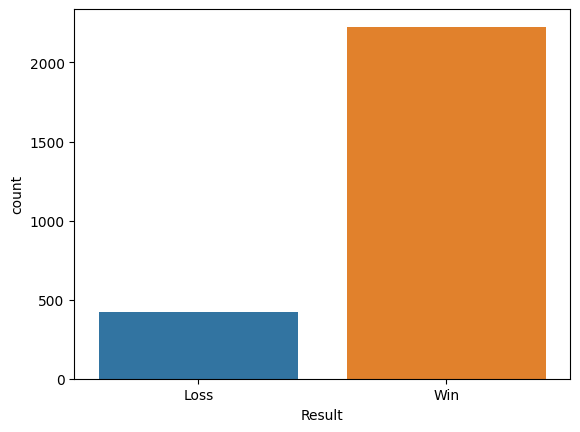

In [54]:
sns.countplot(data=df,x= 'Result');

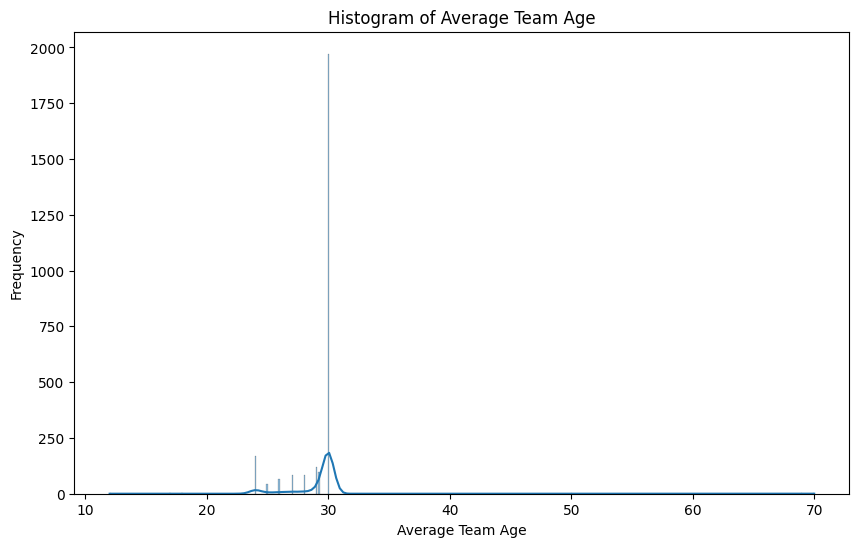

In [55]:
# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Avg_team_Age', kde=True)
plt.title('Histogram of Average Team Age')
plt.xlabel('Average Team Age')
plt.ylabel('Frequency')
plt.show()

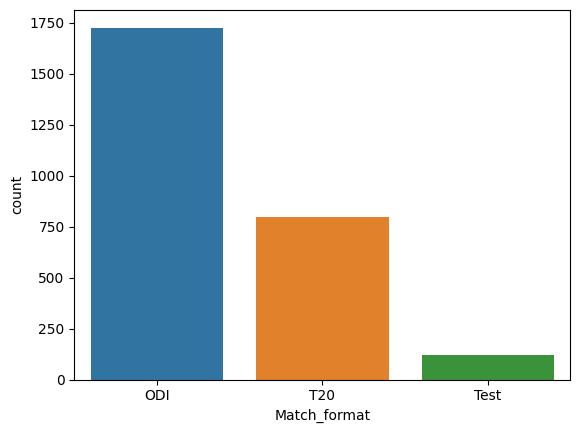

In [56]:
sns.countplot(data=df,x= 'Match_format');

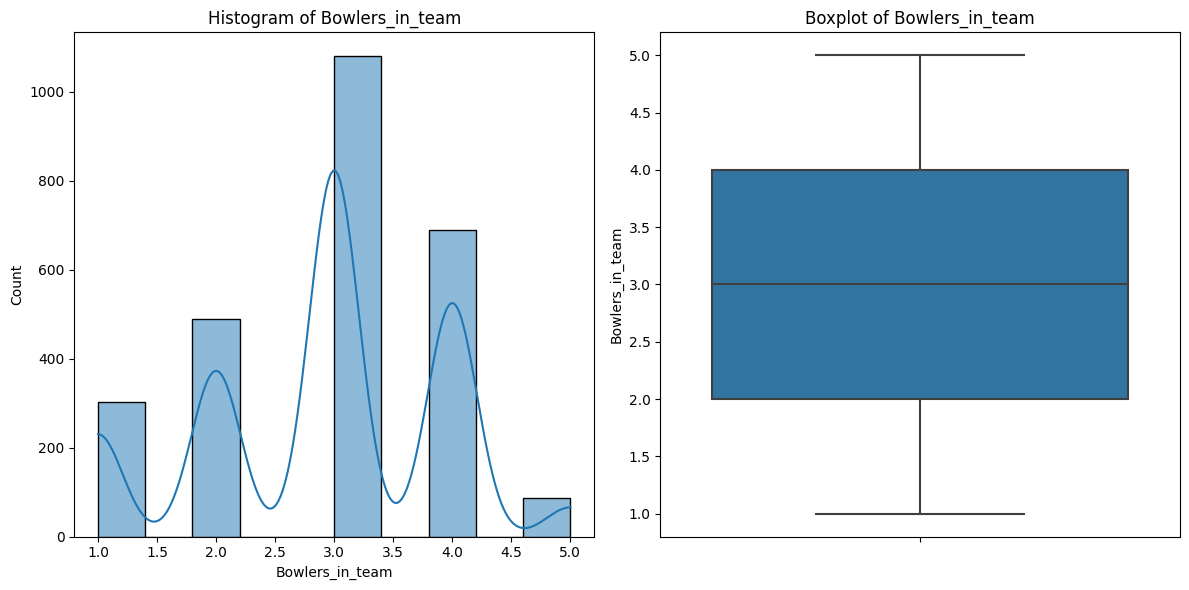

In [57]:
ig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
sns.histplot(df['Bowlers_in_team'], bins=10, kde=True, ax=ax[0])
ax[0].set_title('Histogram of Bowlers_in_team')

# Boxplot
sns.boxplot(y=df['Bowlers_in_team'], ax=ax[1])
ax[1].set_title('Boxplot of Bowlers_in_team')

plt.tight_layout()
plt.show()

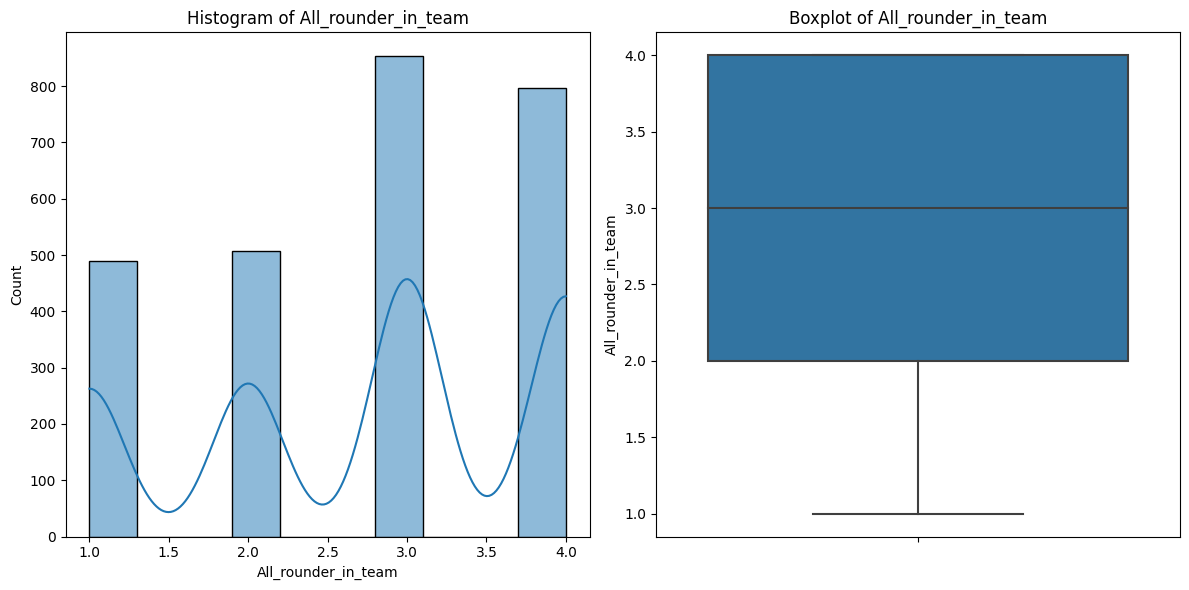

In [58]:
ig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
sns.histplot(df['All_rounder_in_team'], bins=10, kde=True, ax=ax[0])
ax[0].set_title('Histogram of All_rounder_in_team')

# Boxplot
sns.boxplot(y=df['All_rounder_in_team'], ax=ax[1])
ax[1].set_title('Boxplot of All_rounder_in_team')

plt.tight_layout()
plt.show()

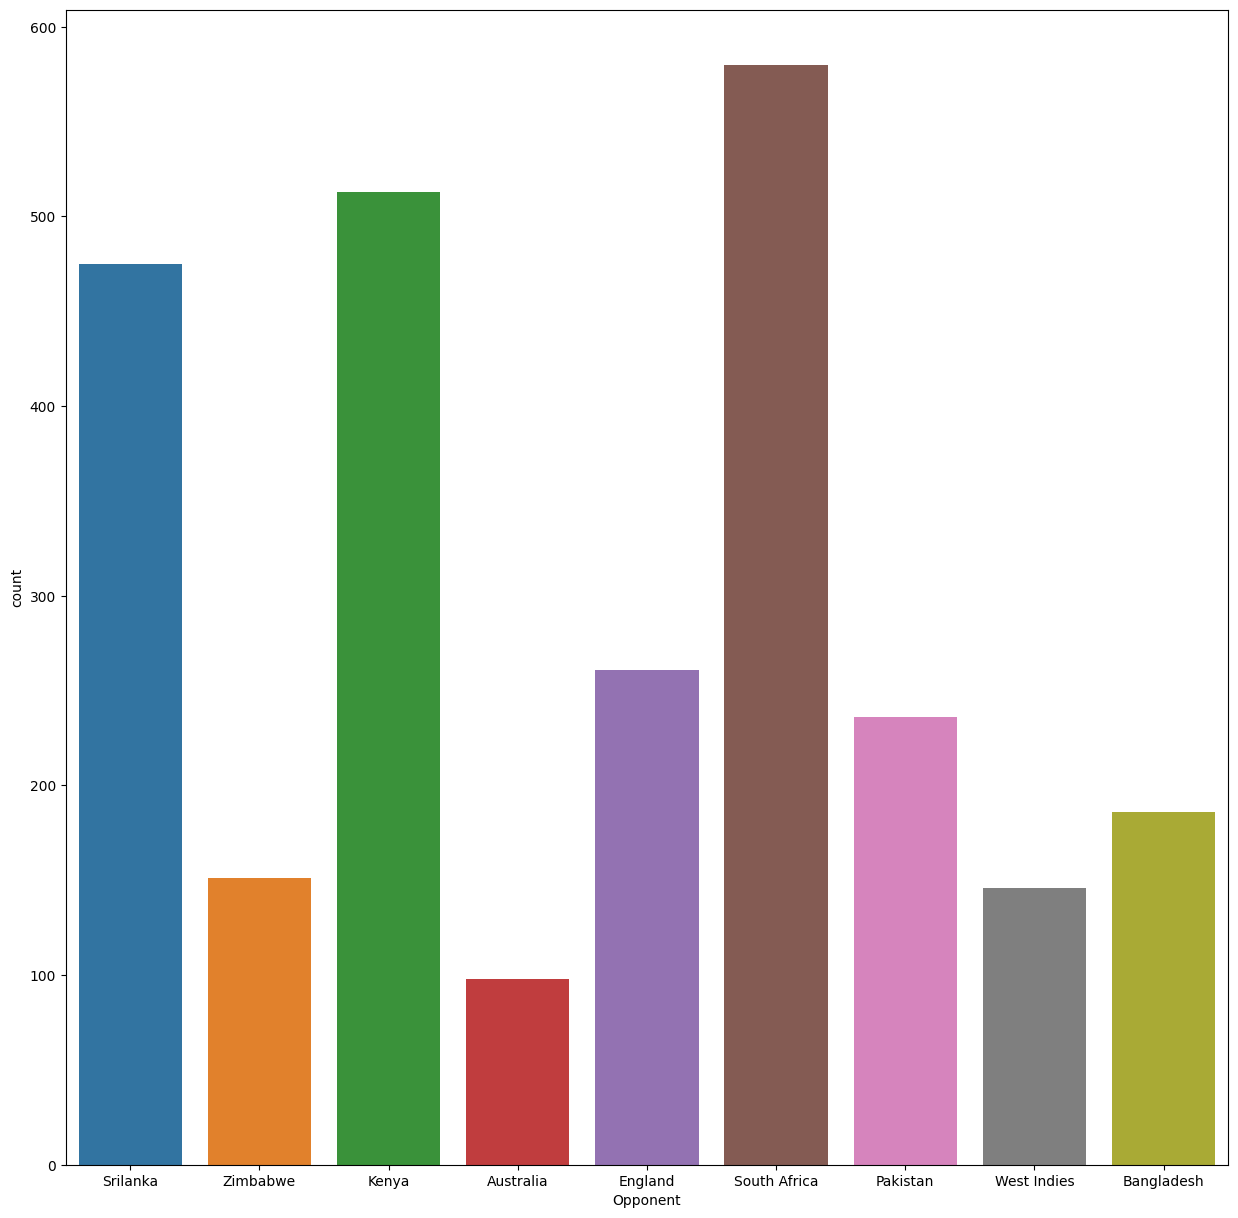

In [59]:
plt.figure(figsize=(15,15))
sns.countplot(data=df,x= 'Opponent');

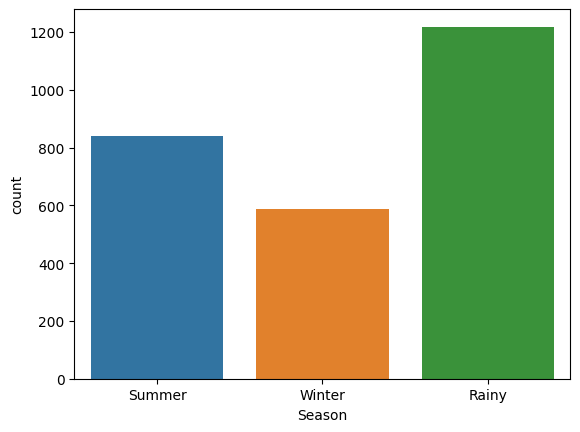

In [60]:
sns.countplot(data=df,x= 'Season');

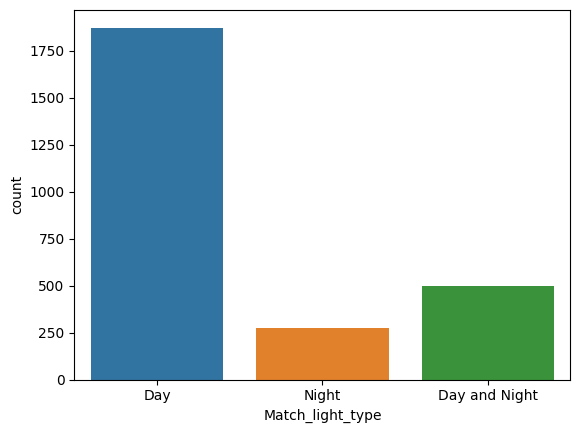

In [61]:
sns.countplot(data=df,x= 'Match_light_type');

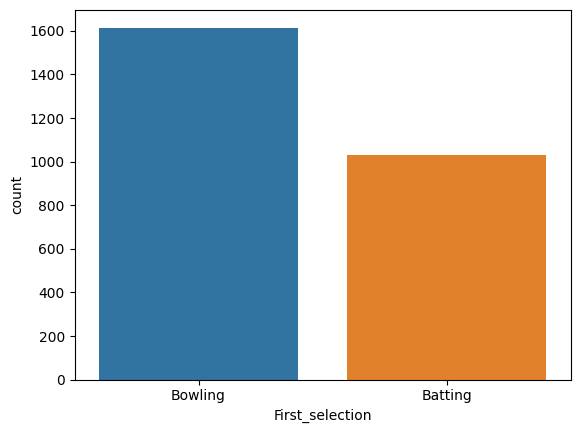

In [62]:
sns.countplot(data=df,x= 'First_selection');

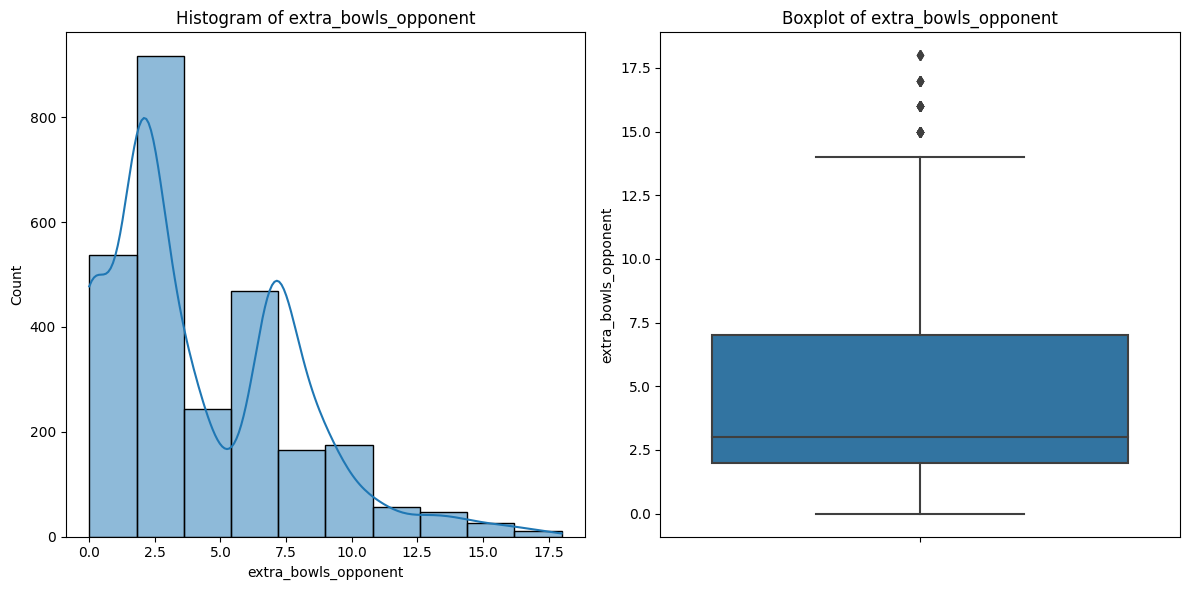

In [63]:
ig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
sns.histplot(df['extra_bowls_opponent'], bins=10, kde=True, ax=ax[0])
ax[0].set_title('Histogram of extra_bowls_opponent')

# Boxplot
sns.boxplot(y=df['extra_bowls_opponent'], ax=ax[1])
ax[1].set_title('Boxplot of extra_bowls_opponent')

plt.tight_layout()
plt.show()

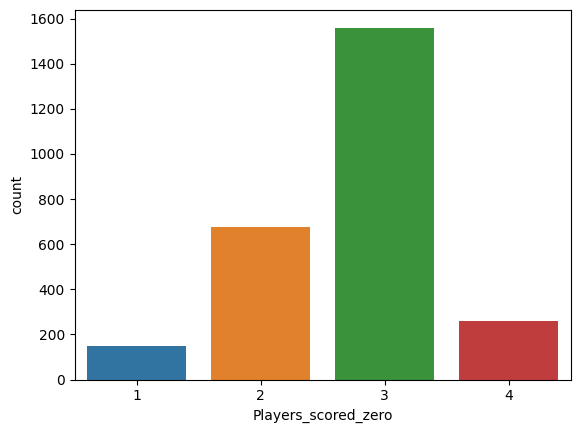

In [64]:
sns.countplot(data=df,x= 'Players_scored_zero');

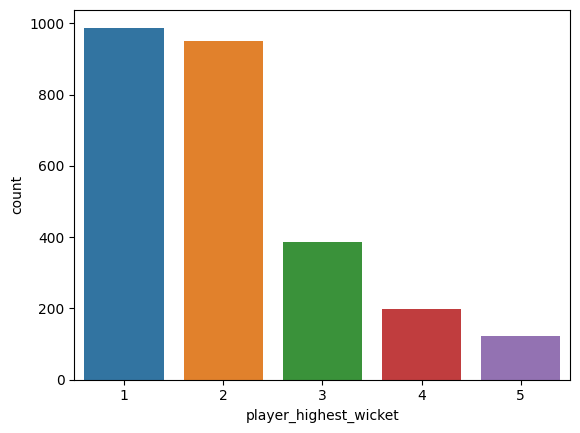

In [65]:
sns.countplot(data=df,x= 'player_highest_wicket');

## Bivariate Analysis

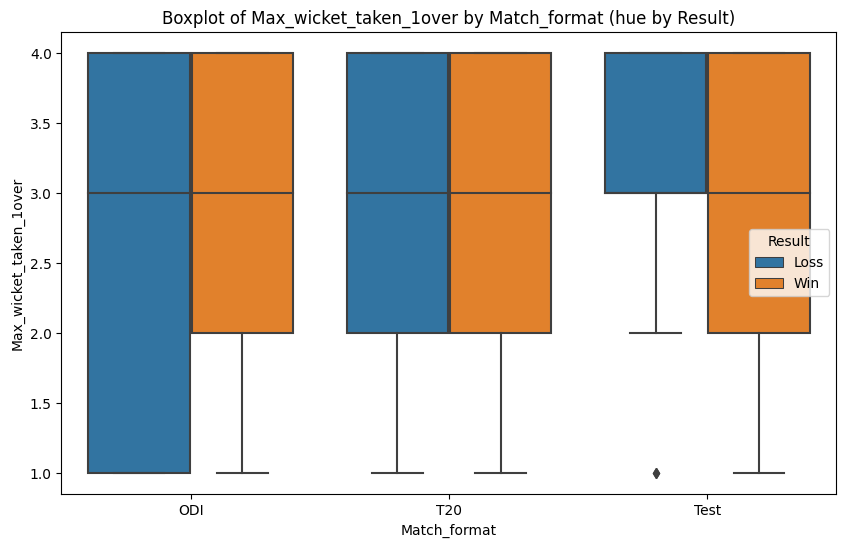

In [66]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Match_format", y="Max_wicket_taken_1over", hue="Result", data=df)
plt.title('Boxplot of Max_wicket_taken_1over by Match_format (hue by Result)')
plt.xlabel('Match_format')
plt.ylabel('Max_wicket_taken_1over')
plt.legend(title='Result')
plt.show()


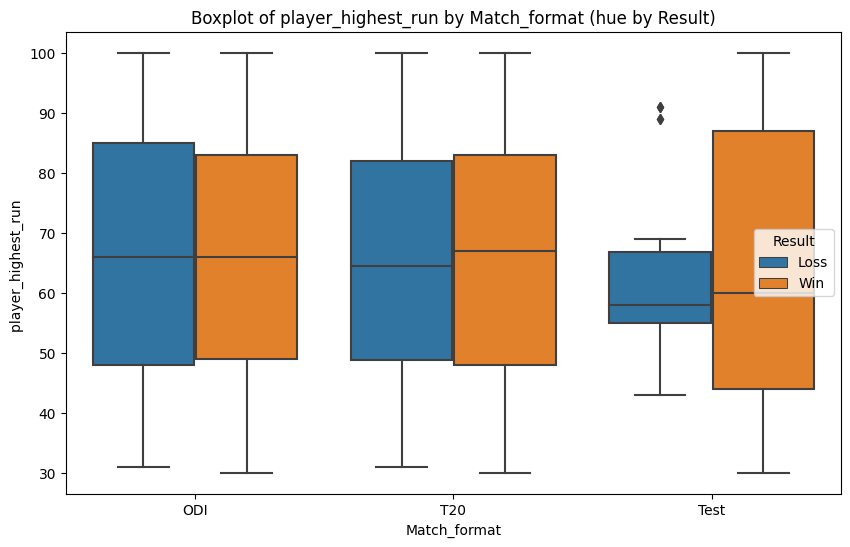

In [67]:

plt.figure(figsize=(10, 6))
sns.boxplot(x="Match_format", y="player_highest_run", hue="Result", data=df)
plt.title('Boxplot of player_highest_run by Match_format (hue by Result)')
plt.xlabel('Match_format')
plt.ylabel('player_highest_run ')
plt.legend(title='Result')
plt.show()


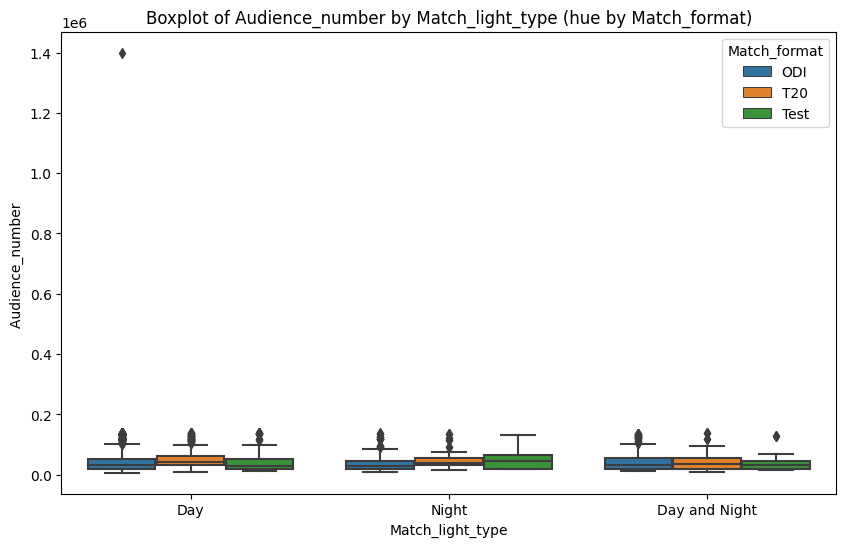

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Match_light_type", y="Audience_number", hue="Match_format", data=df)
plt.title('Boxplot of Audience_number by Match_light_type (hue by Match_format)')
plt.xlabel('Match_light_type')
plt.ylabel('Audience_number ')
plt.legend(title='Match_format')
plt.show()

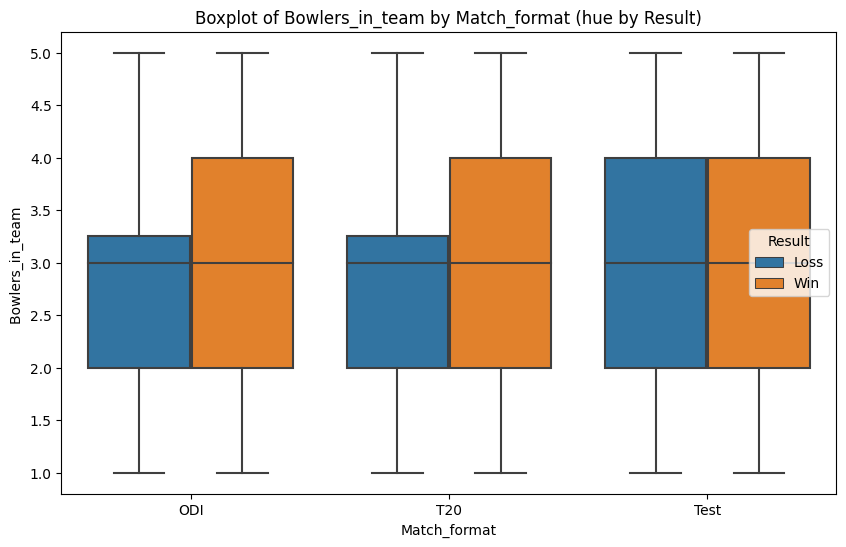

In [69]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Match_format", y="Bowlers_in_team", hue="Result", data=df)
plt.title('Boxplot of Bowlers_in_team by Match_format (hue by Result)')
plt.xlabel('Match_format')
plt.ylabel('Bowlers_in_team ')
plt.legend(title='Result')
plt.show()

## Correlation

C:\Users\POONAM TEKWANI\AppData\Local\Temp\ipykernel_13740\1656061046.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='viridis')


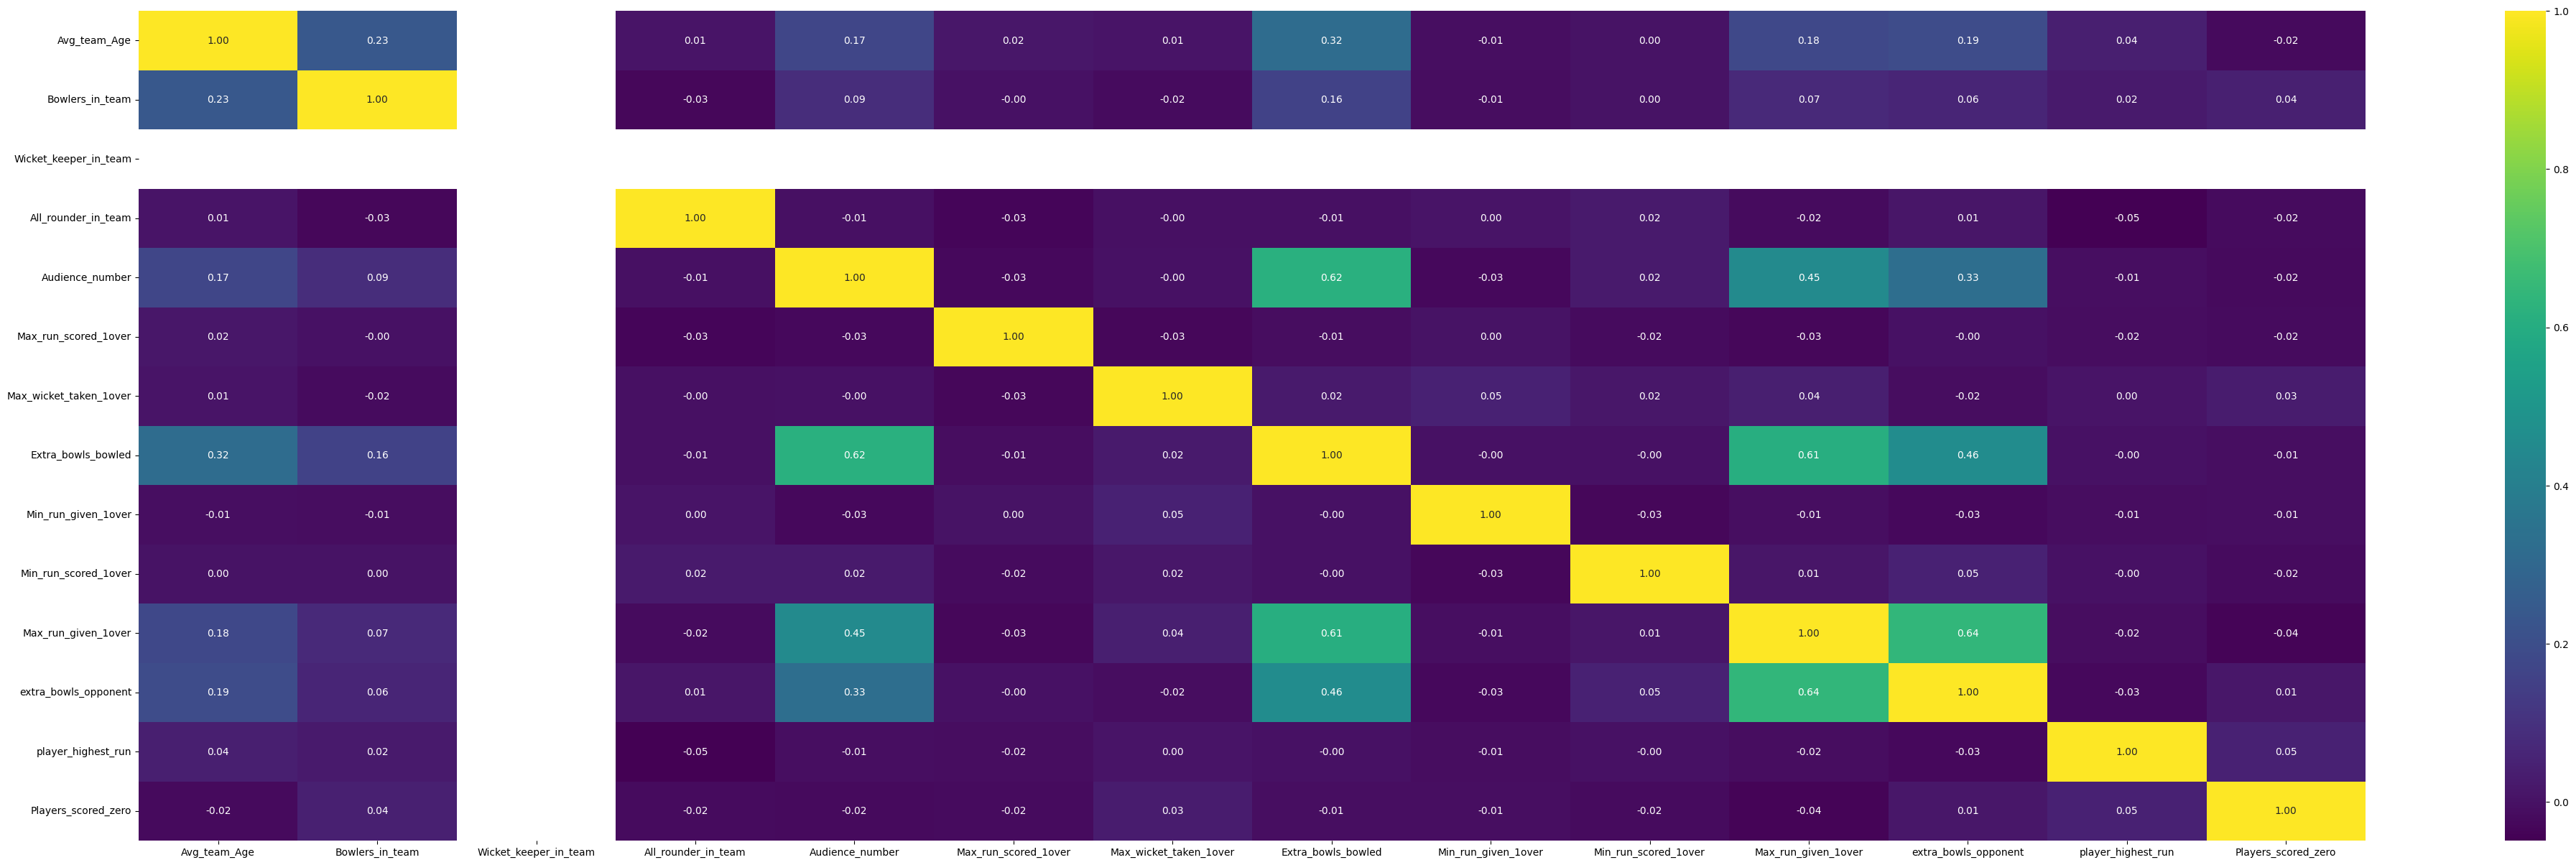

In [70]:
plt.figure(figsize=(50, 15))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='viridis')
plt.show()

## Variable transformation

In [71]:
for i in df.columns:
    if df[i].dtype == "object":
        df[i]= pd.Categorical(df[i]).codes

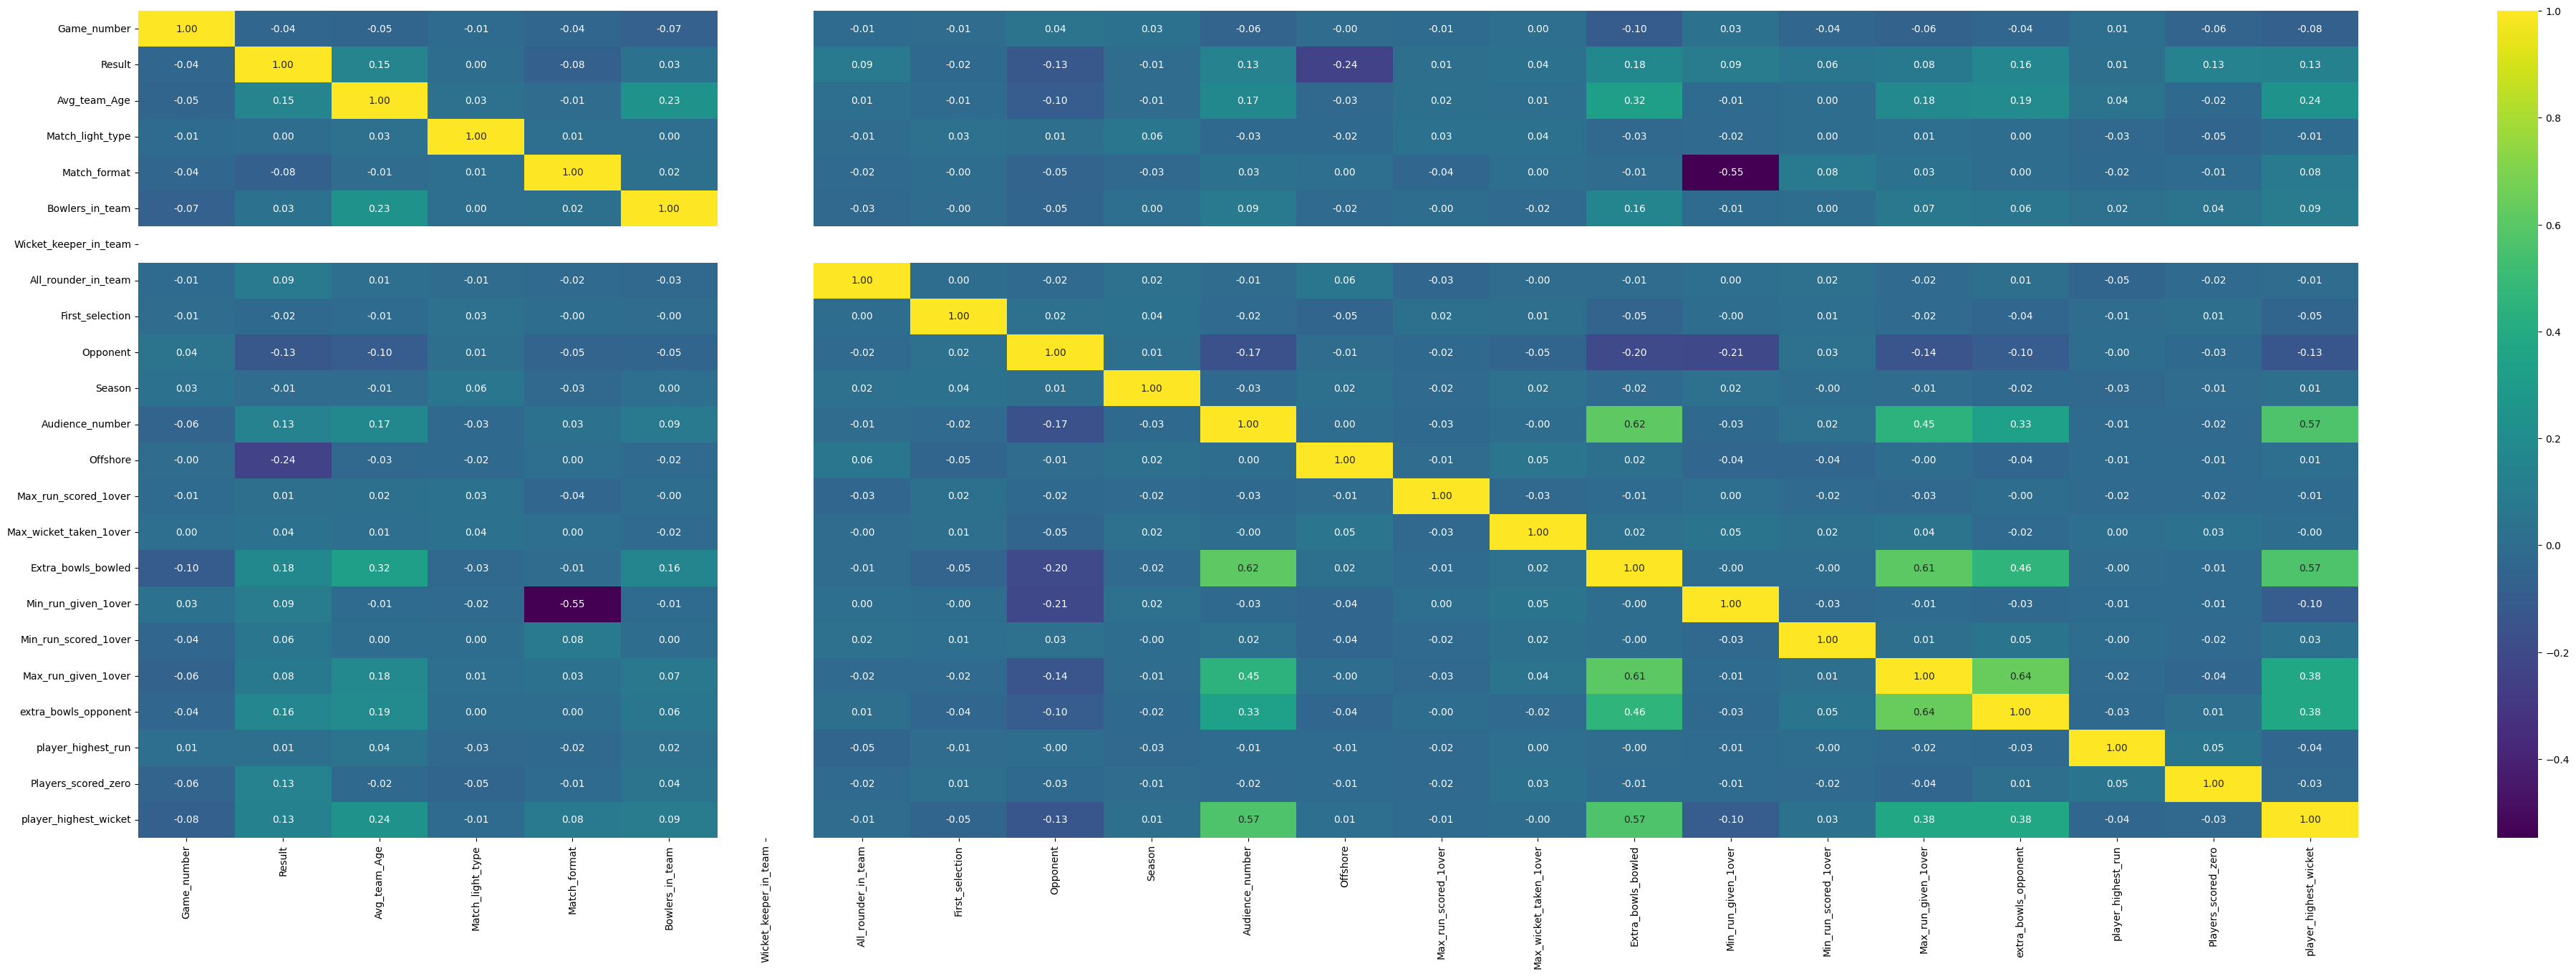

In [72]:
plt.figure(figsize=(50, 15))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='viridis')
plt.show()

## Removal of unwanted variables 

In [73]:
df = df.drop(["Audience_number","Game_number","Offshore", "Wicket_keeper_in_team"],axis = 1)

In [74]:
df.shape

(2646, 19)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Result                  2646 non-null   int8   
 1   Avg_team_Age            2646 non-null   float64
 2   Match_light_type        2646 non-null   int8   
 3   Match_format            2646 non-null   int8   
 4   Bowlers_in_team         2646 non-null   float64
 5   All_rounder_in_team     2646 non-null   float64
 6   First_selection         2646 non-null   int8   
 7   Opponent                2646 non-null   int8   
 8   Season                  2646 non-null   int8   
 9   Max_run_scored_1over    2646 non-null   float64
 10  Max_wicket_taken_1over  2646 non-null   int64  
 11  Extra_bowls_bowled      2646 non-null   float64
 12  Min_run_given_1over     2646 non-null   int64  
 13  Min_run_scored_1over    2646 non-null   float64
 14  Max_run_given_1over     2646 non-null   

In [76]:

# Select numerical columns
df_num = df.select_dtypes(include=[np.number])

# Select categorical columns
df_cat = df.select_dtypes(exclude=[np.number])


## Outlier treatment 

In [77]:
## checking if there are any outliers in each and every column.

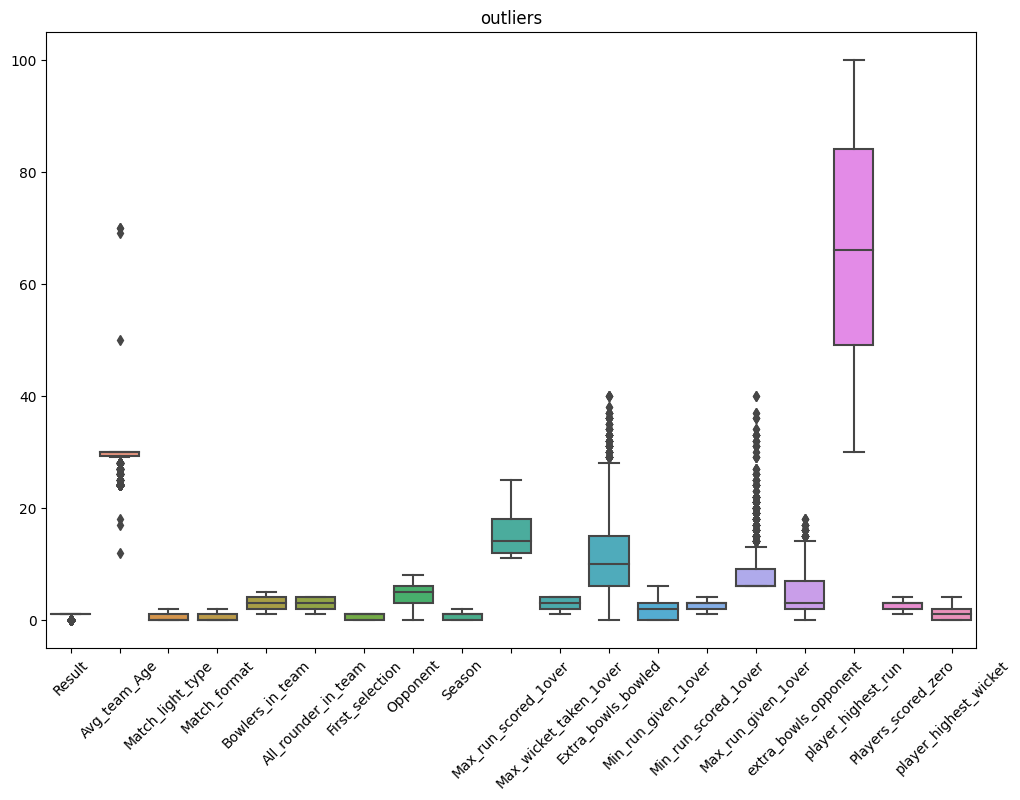

In [78]:

# Create boxplots for numerical columns
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_num)
plt.title('outliers')
plt.xticks(rotation=45)
plt.show()



In [79]:
## Treating outliers with IQR method

In [80]:
def treat_outliers_iqr(data):
   
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Calculate lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Treat outliers by replacing with the nearest bound
    treated_data = np.where(data < lower_bound, lower_bound,
                            np.where(data > upper_bound, upper_bound, data))
    
    return treated_data

# Treat outliers in each numerical column of df_num using the IQR method
for column in df_num.columns:
    df_num[column] = treat_outliers_iqr(df_num[column])


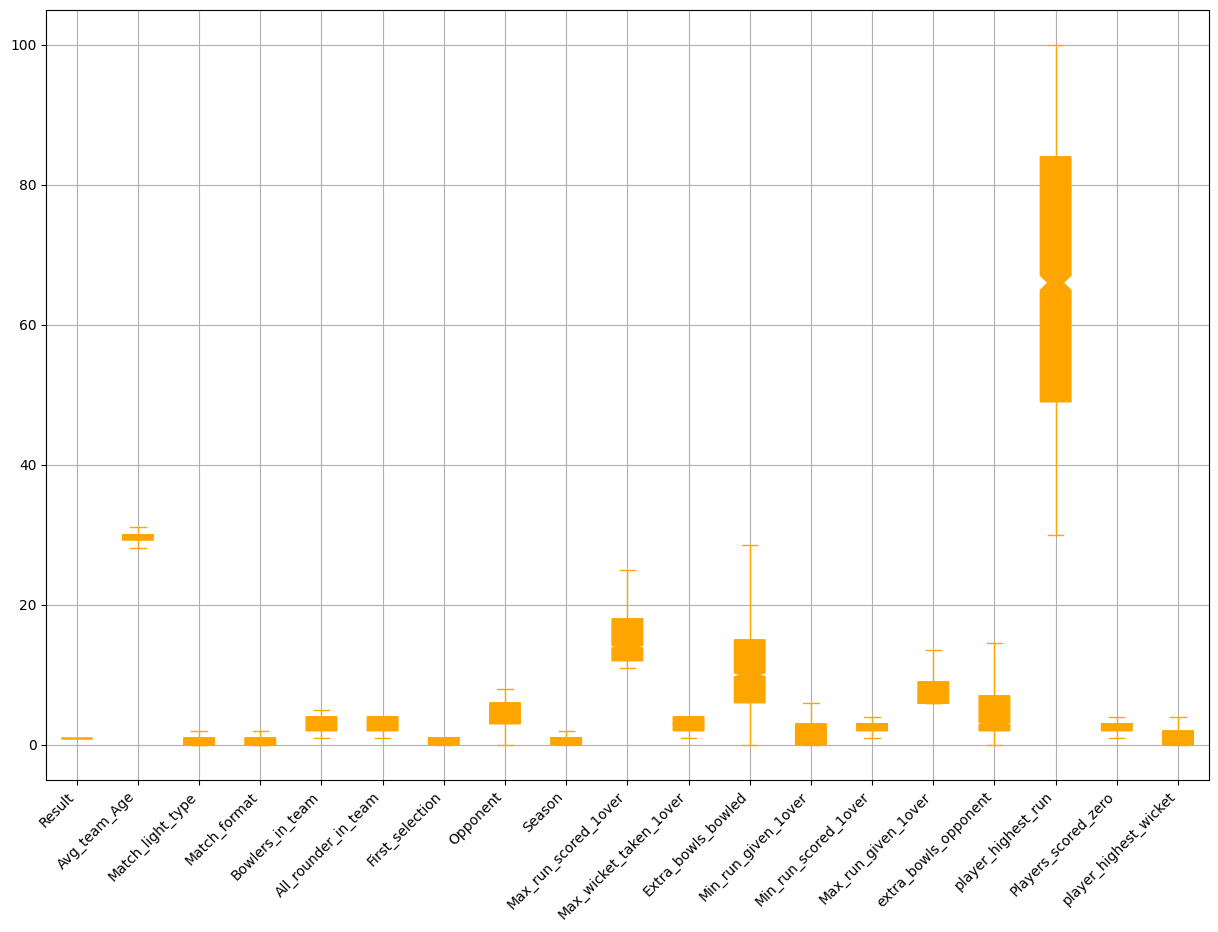

In [81]:
plt.figure(figsize=(15,10))
boxplot = df_num.boxplot(patch_artist=True, color='orange', notch=True)
boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right')
plt.show()


## Checking the dataset is balanced if not then applying technique

In [82]:
# Assuming 'Result' is the target variable or class labels column
class_frequencies = df['Result'].value_counts()

# Print class frequencies
print("Class Frequencies:")
print(class_frequencies)

# Calculate percentage of each class
class_percentages = df['Result'].value_counts(normalize=True)

# Print class percentages
print("\nClass Percentages:")
print(class_percentages)



Class Frequencies:
1    2226
0     420
Name: Result, dtype: int64

Class Percentages:
1    0.84127
0    0.15873
Name: Result, dtype: float64


1    2226
0     420
Name: Result, dtype: int64


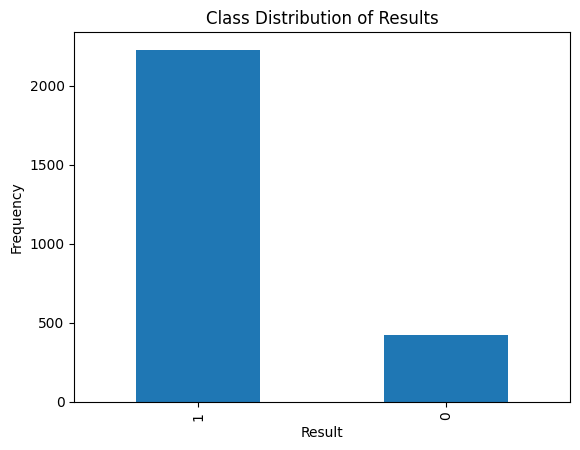

In [83]:
# Check the distribution of the 'Result' column
distribution = df['Result'].value_counts()

print(distribution)

# Plot the distribution
distribution.plot(kind='bar')
plt.title('Class Distribution of Results')
plt.xlabel('Result')
plt.ylabel('Frequency')
plt.show()


The output indicates that our dataset is unbalanced. There are 2,226 instances of class 1 and only 420 instances of class 0. To address this imbalance, you can apply resampling techniques such as oversampling the minority class (0) or undersampling the majority class (1).

Here’s how you can handle this using the imbalanced-learn library:

Using SMOTE (Synthetic Minority Over-sampling Technique) for Oversampling

In [84]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


## SMOTE "Synthetic Minority Over-sampling Technique."

In [85]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Separate features and target variable
x = df.drop('Result', axis=1)
y = df['Result']

# Split the data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

# check the distribution after resampling
print("resampled class distribution: \n", pd.Series(y_resampled).value_counts())


resampled class distribution: 
 0    1776
1    1776
Name: Result, dtype: int64


resampling process using SMOTE has successfully balanced the class distribution. Now, both classes have 1776 instances, indicating that SMOTE has generated synthetic samples for the minority class (Class 0) to match the number of instances in the majority class (Class 1).

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Train a Random Forest model on the resampled data
rf = RandomForestClassifier(random_state=42)
rf.fit(x_resampled, y_resampled)

# Predict on the test set
y_pred_rf = rf.predict(x_test)

# Evaluate the Random Forest model
print("Random Forest Classifier:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.90      0.69      0.78        80
           1       0.95      0.99      0.97       450

    accuracy                           0.94       530
   macro avg       0.92      0.84      0.87       530
weighted avg       0.94      0.94      0.94       530



Precision: Precision measures the accuracy of positive predictions. For Class 0 (the minority class), it's 0.93, indicating that 93% of the instances predicted as Class 0 are actually Class 0. For Class 1 (the majority class), it's 0.94, indicating that 94% of the instances predicted as Class 1 are actually Class 1.

Recall: Recall measures the proportion of actual positives that were correctly predicted. For Class 0, it's 0.66, indicating that 66% of the actual Class 0 instances were correctly predicted. For Class 1, it's 0.99, indicating that 99% of the actual Class 1 instances were correctly predicted.

F1-score: The F1-score is the harmonic mean of precision and recall. It provides a balance between precision and recall. For Class 0, it's 0.77, and for Class 1, it's 0.97.

Support: Support is the number of actual occurrences of each class in the specified dataset. Class 0 has 80 instances, and Class 1 has 450 instances.

Accuracy: Accuracy measures the overall correctness of the model. In this case, it's 94%, indicating that 94% of the predictions made by the model are correct.

Macro Avg and Weighted Avg: These are the averages of precision, recall, and F1-score, calculated separately for each class and then averaged. Macro Avg gives equal weight to each class, while Weighted Avg gives weight proportional to the number of true instances for each class.

Overall, the Random Forest Classifier appears to perform well on our dataset, achieving high precision, recall, and F1-score for both classes. 

## Data is balanced

0    1776
1    1776
Name: Result, dtype: int64


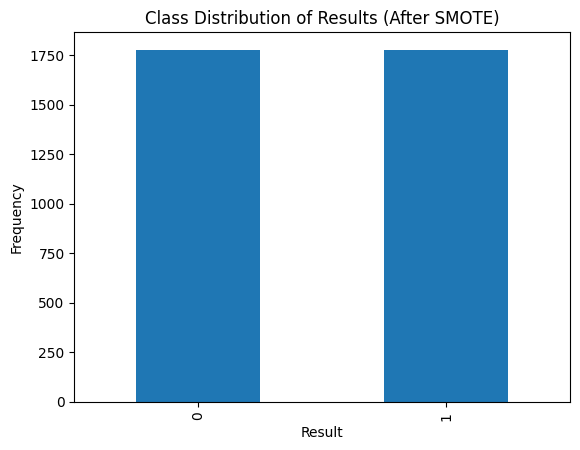

In [87]:
# Combine resampled features and target into a DataFrame
resampled_df = pd.concat([pd.DataFrame(x_resampled, columns=x.columns), pd.Series(y_resampled, name='Result')], axis=1)

# Check the distribution of the 'Result' column in the resampled data
resampled_distribution = resampled_df['Result'].value_counts()

print(resampled_distribution)

# Plot the distribution
resampled_distribution.plot(kind='bar')
plt.title('Class Distribution of Results (After SMOTE)')
plt.xlabel('Result')
plt.ylabel('Frequency')
plt.show()


## business insights using clustering

In [88]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardize the numerical data
scaler = StandardScaler()
num_scaled = scaler.fit_transform(df_num)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(num_scaled)

# Add cluster labels to the DataFrame
df_num['Cluster'] = clusters

# Analyze cluster centers
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df_num.columns[:-1]) # Exclude the 'Cluster' column
print("Cluster Centers:")
print(cluster_centers)


C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


Cluster Centers:
   Result  Avg_team_Age  Match_light_type  Match_format  Bowlers_in_team  \
0     1.0     29.511824          0.385491      1.120910         2.870555   
1     1.0     29.450777          0.388657      0.003336         2.882402   
2     1.0     29.937567          0.419355      0.331989         3.000000   

   All_rounder_in_team  First_selection  Opponent    Season  \
0             2.704125         0.600284  4.935989  0.769559   
1             2.704754         0.644704  4.150959  0.795663   
2             2.826613         0.564516  3.661290  0.701613   

   Max_run_scored_1over  Max_wicket_taken_1over  Extra_bowls_bowled  \
0             15.051209                2.692745            8.436700   
1             15.297748                2.700584            7.989992   
2             15.216398                2.743280           18.436156   

   Min_run_given_1over  Min_run_scored_1over  Max_run_given_1over  \
0             0.310100              2.839260             6.731152   
1 

Team Composition Insights:

Cluster 0 exhibits a balanced team composition with a higher number of bowlers and all-rounders compared to Clusters 1 and 2. This suggests a strategy focused on versatility and depth in skills.
Cluster 1 also maintains a balanced team composition, although with slightly fewer bowlers and all-rounders compared to Cluster 0.
Cluster 2 has the lowest average number of bowlers and all-rounders, indicating a different team strategy with potentially more specialized player roles.
Match Performance Insights:

Cluster 0 demonstrates strong match performance, as evidenced by higher average values for metrics such as 'Max_run_scored_1over', 'Max_wicket_taken_1over', and 'player_highest_run'. This suggests a tendency towards aggressive gameplay and higher individual player contributions.
Cluster 1 shows good match performance, albeit slightly lower than Cluster 0, indicating a competitive level of gameplay and overall team effectiveness.
Cluster 2 exhibits relatively weaker match performance metrics compared to Clusters 0 and 1, suggesting areas for improvement in performance and strategy.
Opponent Analysis:

Teams in Cluster 0 face tougher opponents on average, as indicated by the higher average value for 'Opponent'. This suggests a higher level of competition and the need for strategic planning and adaptability.
Cluster 1 faces opponents of moderate difficulty, falling between Cluster 0 and Cluster 2 in terms of average opponent strength.
Cluster 2 faces relatively weaker opponents, indicating potential opportunities for teams in this cluster to capitalize on weaker opposition.
Seasonal Trends:

Cluster 0 may exhibit seasonal variations in performance, with potentially higher participation or stronger performance in certain seasons, as indicated by the higher average value for 'Season'.
Cluster 1 shows moderate participation or performance across seasons, with an average value for 'Season' between Cluster 0 and Cluster 2.
Cluster 2 may have consistent or lower participation or performance across seasons compared to Clusters 0 and 1.
Player Performance Insights:

Individual player performances in Cluster 0 are characterized by higher average values for 'player_highest_run' and 'player_highest_wicket', indicating stronger individual contributions and performances.
Cluster 1 exhibits moderate individual player performances, falling between Cluster 0 and Cluster 2 in terms of average player performance metrics.
Cluster 2 shows relatively weaker individual player performances compared to Clusters 0 and 1, suggesting areas for improvement or player development.
Scoring and Bowling Efficiency:

Cluster 0 demonstrates high efficiency in both scoring ('Min_run_scored_1over') and bowling ('Min_run_given_1over') compared to Clusters 1 and 2, indicating effective utilization of resources and tactical acumen.
Cluster 1 shows moderate efficiency in scoring and bowling metrics, reflecting a balanced approach to gameplay and strategy.
Cluster 2 exhibits relatively lower efficiency in scoring and bowling, suggesting opportunities for improvement in execution and performance.

# NOTES 2

1. Model building and interpretation.
a. Build various models (You can choose to build models for either or all of descriptive, predictive or prescriptive purposes) b. Test your predictive model against the test set using various appropriate performance metrics c.Interpretation of the model(s)

# a. Build various models

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and fit Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [90]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and fit Decision Tree model
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [91]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and fit Random Forest model
rand_forest = RandomForestClassifier(random_state=42)
rand_forest.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

# b. Test your predictive model against the test set using various appropriate performance metrics .

In [92]:
# Predict using the model
y_pred_log_reg = log_reg.predict(x_test)

In [93]:
# Predict using the model
y_pred_dec_tree = dec_tree.predict(x_test)

In [94]:
# Predict using the model
y_pred_rand_forest = rand_forest.predict(x_test)

In [95]:
from sklearn.metrics import confusion_matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
cm_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)
cm_rand_forest = confusion_matrix(y_test, y_pred_rand_forest)

In [96]:
print("Confusion Matrix - Logistic Regression:")
print(cm_log_reg)
print("\n")

print("Confusion Matrix - Decision Tree:")
print(cm_dec_tree)
print("\n")

print("Confusion Matrix - Random Forest:")
print(cm_rand_forest)


Confusion Matrix - Logistic Regression:
[[  8  72]
 [  5 445]]


Confusion Matrix - Decision Tree:
[[ 62  18]
 [ 16 434]]


Confusion Matrix - Random Forest:
[[ 49  31]
 [  0 450]]


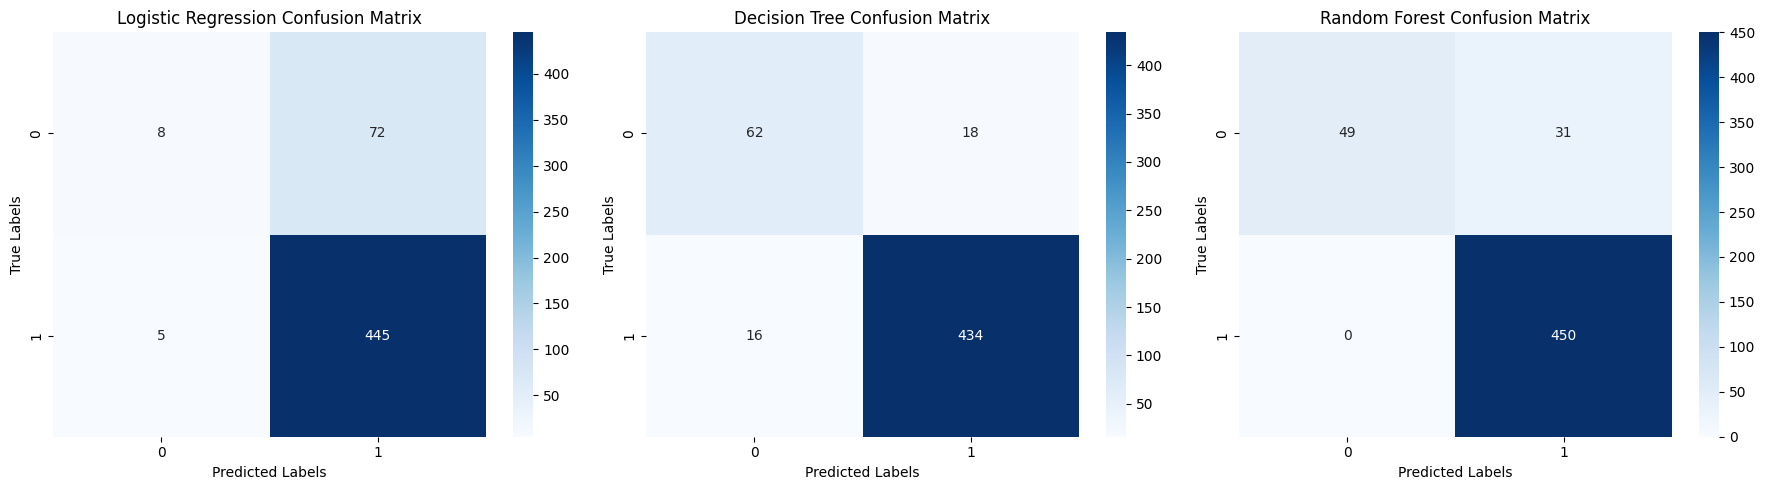

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have defined fig and axes already
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression Confusion Matrix Heatmap
sns.heatmap(cm_log_reg, annot=True, cmap='Blues', fmt='d', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# Decision Tree Confusion Matrix Heatmap
sns.heatmap(cm_dec_tree, annot=True, cmap='Blues', fmt='d', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

# Random Forest Confusion Matrix Heatmap
sns.heatmap(cm_rand_forest, annot=True, cmap='Blues', fmt='d', ax=axes[2])
axes[2].set_title('Random Forest Confusion Matrix')
axes[2].set_xlabel('Predicted Labels')
axes[2].set_ylabel('True Labels')

plt.tight_layout()
plt.show()


In [98]:
# Evaluate the model
metrics_log_reg = {
    "Accuracy": accuracy_score(y_test, y_pred_log_reg),
    "Precision": precision_score(y_test, y_pred_log_reg, average='weighted'),
    "Recall": recall_score(y_test, y_pred_log_reg, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_log_reg, average='weighted'),
    "ROC AUC": roc_auc_score(y_test, log_reg.predict_proba(x_test)[:, 1])
}

# Display evaluation metrics
print("Logistic Regression Model Evaluation Metrics:")
for metric_name, value in metrics_log_reg.items():
    print(f"{metric_name}: {value}")
print("\n")

Logistic Regression Model Evaluation Metrics:
Accuracy: 0.8547169811320755
Precision: 0.8237009878920758
Recall: 0.8547169811320755
F1 Score: 0.8074169232050652
ROC AUC: 0.7409444444444444




In [99]:
# Evaluate the model
metrics_dec_tree = {
    "Accuracy": accuracy_score(y_test, y_pred_dec_tree),
    "Precision": precision_score(y_test, y_pred_dec_tree, average='weighted'),
    "Recall": recall_score(y_test, y_pred_dec_tree, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_dec_tree, average='weighted'),
    "ROC AUC": roc_auc_score(y_test, dec_tree.predict_proba(x_test)[:, 1])
}

# Display evaluation metrics
print("Decision Tree Model Evaluation Metrics:")
for metric_name, value in metrics_dec_tree.items():
    print(f"{metric_name}: {value}")
print("\n")

Decision Tree Model Evaluation Metrics:
Accuracy: 0.9358490566037736
Precision: 0.9352252634102692
Recall: 0.9358490566037736
F1 Score: 0.9355141587545021
ROC AUC: 0.8697222222222223




In [100]:
# Evaluate the model
metrics_rand_forest = {
    "Accuracy": accuracy_score(y_test, y_pred_rand_forest),
    "Precision": precision_score(y_test, y_pred_rand_forest, average='weighted'),
    "Recall": recall_score(y_test, y_pred_rand_forest, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_rand_forest, average='weighted'),
    "ROC AUC": roc_auc_score(y_test, rand_forest.predict_proba(x_test)[:, 1])
}

# Display evaluation metrics
print("Random Forest Model Evaluation Metrics:")
for metric_name, value in metrics_rand_forest.items():
    print(f"{metric_name}: {value}")
print("\n")

Random Forest Model Evaluation Metrics:
Accuracy: 0.9415094339622642
Precision: 0.9452790962224925
Recall: 0.9415094339622642
F1 Score: 0.9354552934080956
ROC AUC: 0.9542083333333333




#  c.Interpretation of the model(s)

In [101]:
# Model Interpretation for Logistic Regression
feature_importance_log_reg = pd.Series(log_reg.coef_[0], index=x_train.columns).sort_values(ascending=False)
print("Logistic Regression Feature Importance:")
print(feature_importance_log_reg)

Logistic Regression Feature Importance:
Players_scored_zero       0.532407
All_rounder_in_team       0.213040
Min_run_scored_1over      0.188401
Min_run_given_1over       0.143734
Avg_team_Age              0.122410
extra_bowls_opponent      0.115724
Max_wicket_taken_1over    0.106955
Match_light_type          0.104861
Extra_bowls_bowled        0.066644
player_highest_wicket     0.056761
Season                    0.024960
Max_run_scored_1over      0.015043
player_highest_run        0.003120
First_selection          -0.057452
Opponent                 -0.075912
Max_run_given_1over      -0.092046
Bowlers_in_team          -0.120096
Match_format             -0.195659
dtype: float64


In [102]:
# Model Interpretation for Decision Tree
feature_importance_dec_tree = pd.Series(dec_tree.feature_importances_, index= x_train.columns).sort_values(ascending=False)
print("Decision Tree Feature Importance:")
print(feature_importance_dec_tree)

Decision Tree Feature Importance:
player_highest_run        0.146138
Extra_bowls_bowled        0.109429
Max_run_scored_1over      0.092182
Players_scored_zero       0.064677
extra_bowls_opponent      0.064068
Match_light_type          0.061151
Bowlers_in_team           0.060612
Min_run_scored_1over      0.060066
Season                    0.054788
Max_wicket_taken_1over    0.053126
Min_run_given_1over       0.041306
player_highest_wicket     0.037276
All_rounder_in_team       0.037212
Opponent                  0.035660
Avg_team_Age              0.027980
First_selection           0.022639
Max_run_given_1over       0.021117
Match_format              0.010571
dtype: float64


In [103]:
# Model Interpretation for Random Forest
feature_importance_rand_forest = pd.Series(rand_forest.feature_importances_, index=x_train.columns).sort_values(ascending=False)
print("Random Forest Feature Importance:")
print(feature_importance_rand_forest)

Random Forest Feature Importance:
player_highest_run        0.122994
Extra_bowls_bowled        0.110229
Max_run_scored_1over      0.084834
extra_bowls_opponent      0.064972
All_rounder_in_team       0.058255
Min_run_scored_1over      0.056570
Max_wicket_taken_1over    0.053533
Players_scored_zero       0.051385
Opponent                  0.050142
Min_run_given_1over       0.048914
Bowlers_in_team           0.048717
Season                    0.045910
Avg_team_Age              0.045677
player_highest_wicket     0.045300
Max_run_given_1over       0.036547
Match_light_type          0.034755
First_selection           0.022195
Match_format              0.019069
dtype: float64


Interpretation:

Accuracy: Random Forest (0.9415) > Decision Tree (0.9358) > Logistic Regression (0.8547)

Precision: Random Forest (0.9453) > Decision Tree (0.9352) > Logistic Regression (0.8237)

Recall: Random Forest (0.9415) = Decision Tree (0.9358) = Logistic Regression (0.8547)

F1 Score: Decision Tree and Random Forest have similar F1 Scores (0.9355), while Logistic Regression has a slightly lower F1 Score (0.8074).

ROC AUC: Random Forest (0.9542) > Decision Tree (0.8697) > Logistic Regression (0.7409)

Analysis:
Accuracy: Both the Decision Tree and Random Forest models outperform the Logistic Regression model in terms of accuracy, with Random Forest slightly edging out the Decision Tree.

Precision and Recall: The Decision Tree and Random Forest models consistently show higher precision and recall compared to Logistic Regression, indicating better performance in correctly identifying positive cases and minimizing false positives.

F1 Score: The F1 scores are highest for the Decision Tree and Random Forest models, suggesting better overall balance between precision and recall.

ROC AUC: The Random Forest model achieves the highest ROC AUC score, indicating superior discrimination ability between positive and negative classes.

Feature Importance: Across all models, certain features consistently appear as important:

player_highest_run
Extra_bowls_bowled
Max_run_scored_1over
extra_bowls_opponent
All_rounder_in_team

Conclusion:
Model Performance: The Random Forest model shows the best performance overall, followed closely by the Decision Tree, while Logistic Regression lags behind in terms of accuracy, F1 score, and ROC AUC.

Feature Importance: Features related to player performance (such as highest runs and wickets), bowling statistics, and team composition (like all-rounders) consistently play significant roles across different models.

When choosing a model, consider the trade-offs between interpretability (Logistic Regression), complexity (Decision Tree), and robustness (Random Forest). The Random Forest model appears to be the strongest performer in this context, offering high accuracy and robustness in predictions.

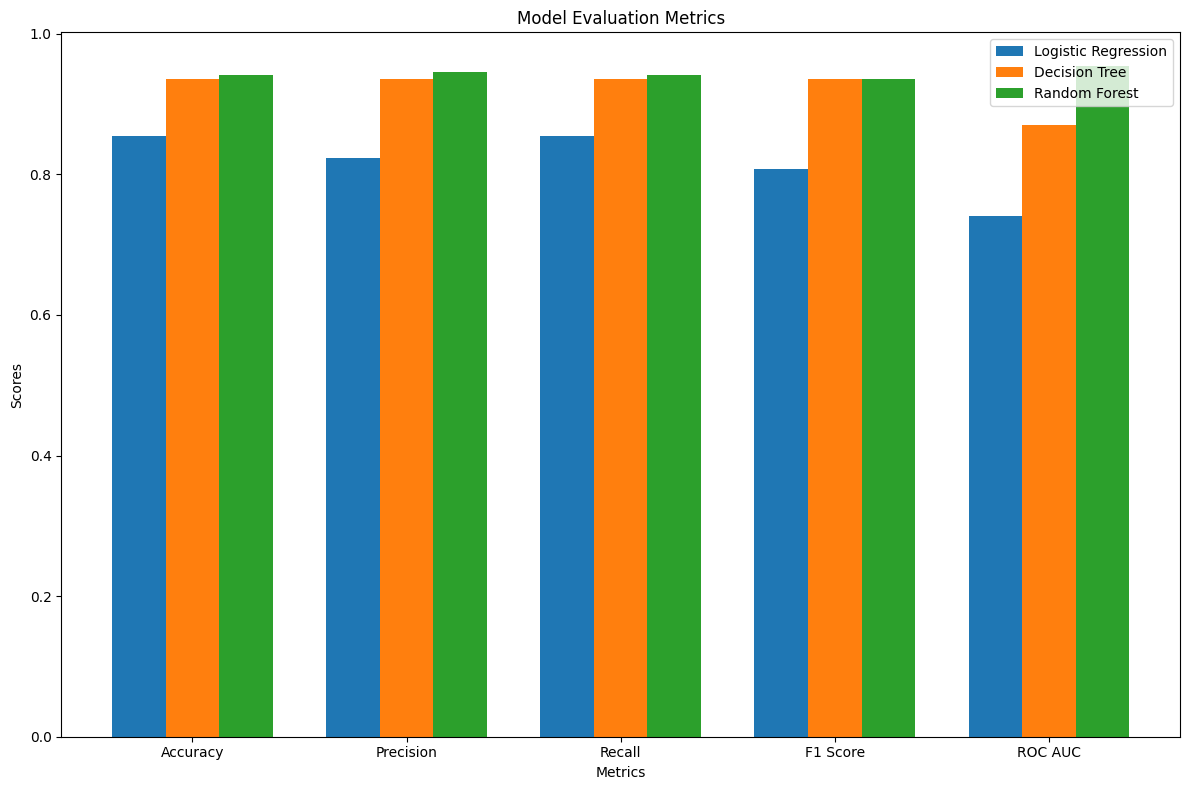

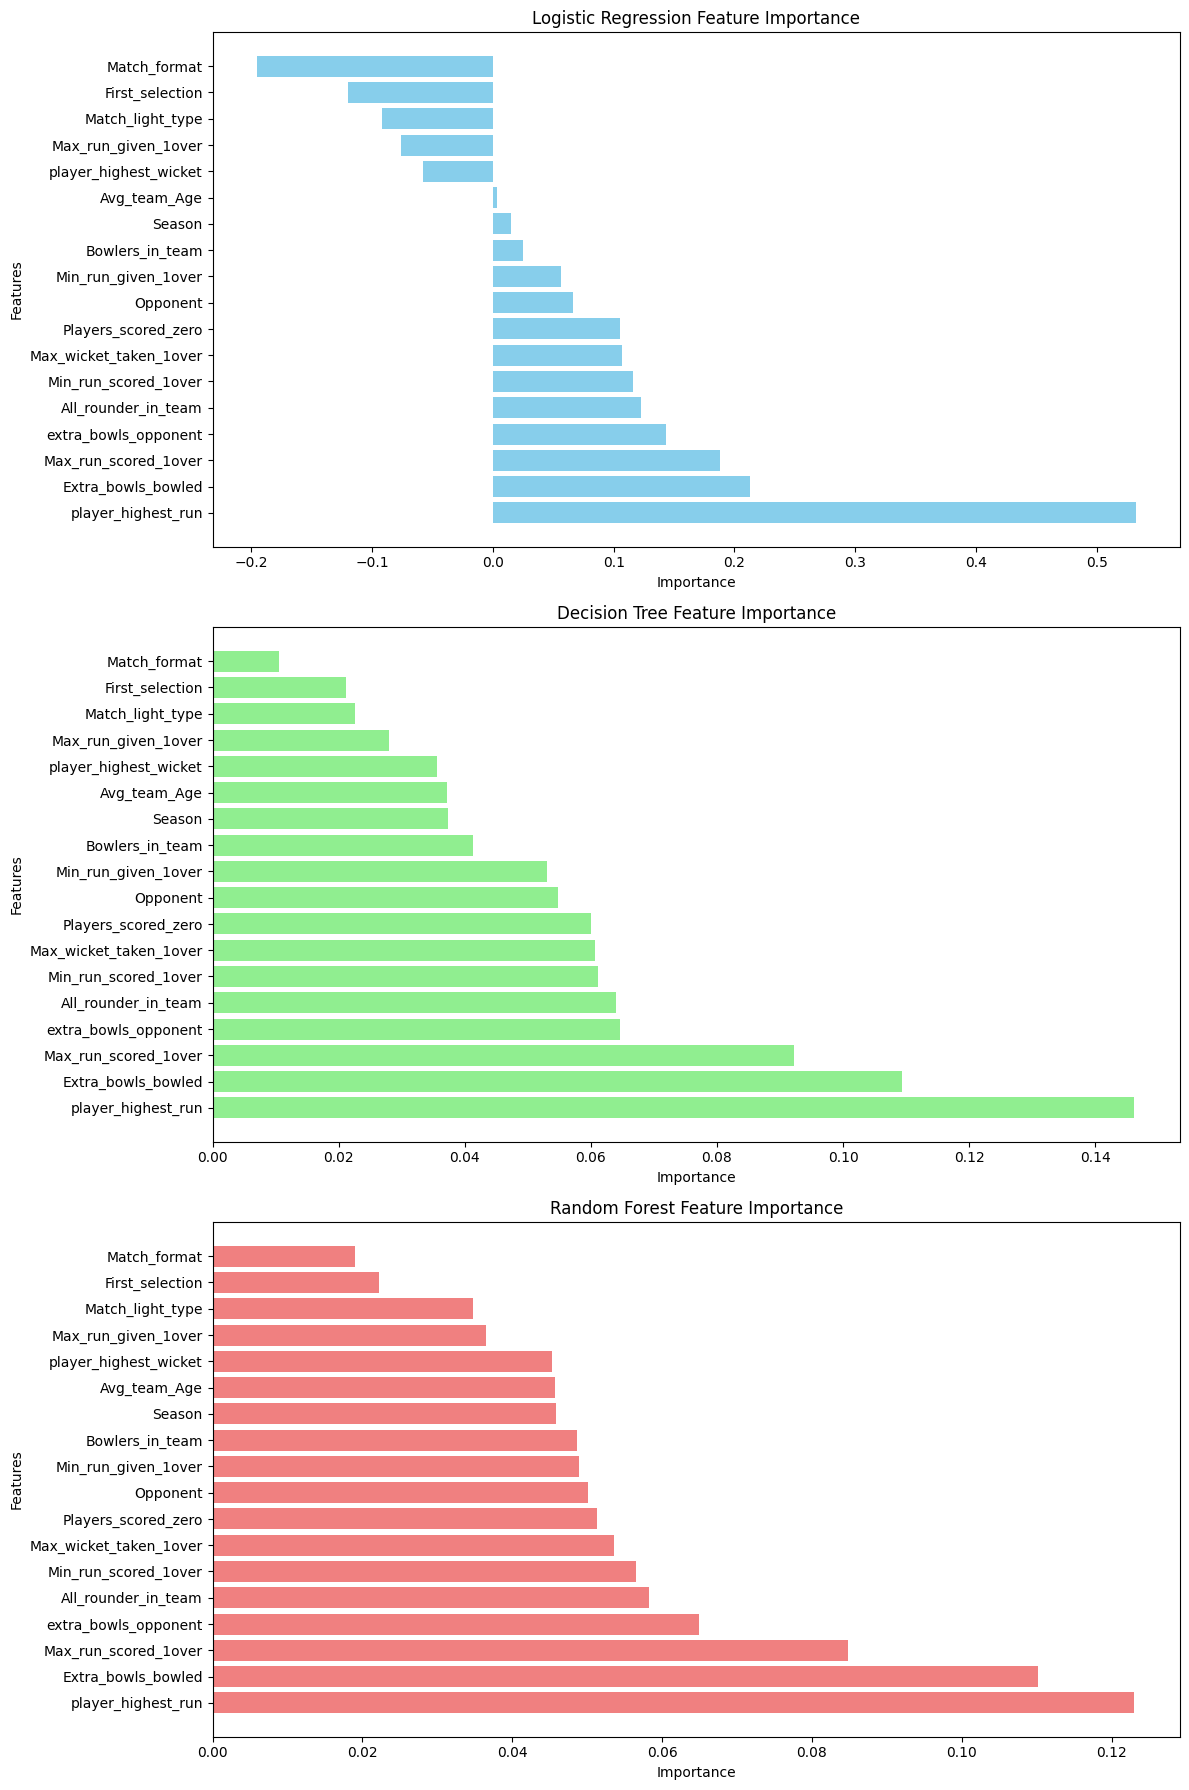

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics and their values for each model
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
logistic_regression_metrics = [0.8547, 0.8237, 0.8547, 0.8074, 0.7409]
decision_tree_metrics = [0.9358, 0.9352, 0.9358, 0.9355, 0.8697]
random_forest_metrics = [0.9415, 0.9453, 0.9415, 0.9355, 0.9542]

# Define feature importance values for each model
features = [
    "player_highest_run", "Extra_bowls_bowled", "Max_run_scored_1over",
    "extra_bowls_opponent", "All_rounder_in_team", "Min_run_scored_1over",
    "Max_wicket_taken_1over", "Players_scored_zero", "Opponent",
    "Min_run_given_1over", "Bowlers_in_team", "Season", "Avg_team_Age",
    "player_highest_wicket", "Max_run_given_1over", "Match_light_type",
    "First_selection", "Match_format"
]

logistic_regression_importance = [
    0.532407, 0.213040, 0.188401, 0.143734, 0.122410, 0.115724, 0.106955, 
    0.104861, 0.066644, 0.056761, 0.024960, 0.015043, 0.003120, -0.057452, 
    -0.075912, -0.092046, -0.120096, -0.195659
]

decision_tree_importance = [
    0.146138, 0.109429, 0.092182, 0.064677, 0.064068, 0.061151, 0.060612, 
    0.060066, 0.054788, 0.053126, 0.041306, 0.037276, 0.037212, 0.035660, 
    0.027980, 0.022639, 0.021117, 0.010571
]

random_forest_importance = [
    0.122994, 0.110229, 0.084834, 0.064972, 0.058255, 0.056570, 0.053533, 
    0.051385, 0.050142, 0.048914, 0.048717, 0.045910, 0.045677, 0.045300, 
    0.036547, 0.034755, 0.022195, 0.019069
]

# Plotting the evaluation metrics
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - width, logistic_regression_metrics, width, label='Logistic Regression')
rects2 = ax.bar(x, decision_tree_metrics, width, label='Decision Tree')
rects3 = ax.bar(x + width, random_forest_metrics, width, label='Random Forest')

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Model Evaluation Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

fig.tight_layout()
plt.show()

# Plotting feature importance for each model
fig, ax = plt.subplots(3, 1, figsize=(12, 18))

ax[0].barh(features, logistic_regression_importance, color='skyblue')
ax[0].set_title('Logistic Regression Feature Importance')

ax[1].barh(features, decision_tree_importance, color='lightgreen')
ax[1].set_title('Decision Tree Feature Importance')

ax[2].barh(features, random_forest_importance, color='lightcoral')
ax[2].set_title('Random Forest Feature Importance')

for a in ax:
    a.set_xlabel('Importance')
    a.set_ylabel('Features')

fig.tight_layout()
plt.show()


2. Model Tuning
a.Ensemble modelling, wherever applicable b. Any other model tuning measures(if applicable) c. Interpretation of the most optimum model and its implication on the business

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Result                  2646 non-null   int8   
 1   Avg_team_Age            2646 non-null   float64
 2   Match_light_type        2646 non-null   int8   
 3   Match_format            2646 non-null   int8   
 4   Bowlers_in_team         2646 non-null   float64
 5   All_rounder_in_team     2646 non-null   float64
 6   First_selection         2646 non-null   int8   
 7   Opponent                2646 non-null   int8   
 8   Season                  2646 non-null   int8   
 9   Max_run_scored_1over    2646 non-null   float64
 10  Max_wicket_taken_1over  2646 non-null   int64  
 11  Extra_bowls_bowled      2646 non-null   float64
 12  Min_run_given_1over     2646 non-null   int64  
 13  Min_run_scored_1over    2646 non-null   float64
 14  Max_run_given_1over     2646 non-null   

# a.Ensemble modelling

## Random Forest Classifier (Bagging)

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Step 2: Define the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Step 3: Set up parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Step 4: Perform GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)

# Step 5: Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Step 6: Get the best model
best_rf = grid_search.best_estimator_

# Step 7: Evaluate on test set
y_pred = best_rf.predict(x_test)

# Step 8: Print evaluation metrics
print("Random Forest Model Evaluation Metrics after Tuning:")
print(classification_report(y_test, y_pred))

# Optional: Print confusion matrix and ROC AUC score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC AUC Score:")
print(roc_auc_score(y_test, y_pred))


Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Accuracy: 0.9314721887684554
Random Forest Model Evaluation Metrics after Tuning:
              precision    recall  f1-score   support

           0       1.00      0.61      0.76        80
           1       0.94      1.00      0.97       450

    accuracy                           0.94       530
   macro avg       0.97      0.81      0.86       530
weighted avg       0.95      0.94      0.94       530

Confusion Matrix:
[[ 49  31]
 [  0 450]]
ROC AUC Score:
0.80625


## Other model tuning measures

## Gradient Boosting

In [117]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Step 1: Initialize the Gradient Boosting classifier
gbm = GradientBoostingClassifier(random_state=42)

# Step 2: Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5],
    'max_depth': [3, 5, 7]
}

# Step 3: Perform GridSearchCV
grid_search = GridSearchCV(estimator=gbm, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)

# Step 4: Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Step 5: Get the best model
best_gbm = grid_search.best_estimator_

# Step 6: Evaluate on test set
y_pred_gbm = best_gbm.predict(x_test)

# Step 7: Print evaluation metrics
print("Gradient Boosting Machine Evaluation Metrics:")
print(classification_report(y_test, y_pred_gbm))

# Optional: Print confusion matrix and ROC AUC score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gbm))

print("ROC AUC Score:")
print(roc_auc_score(y_test, y_pred_gbm))


Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50}
Best CV Accuracy: 0.9291103528257281
Gradient Boosting Machine Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.92      0.61      0.74        80
           1       0.94      0.99      0.96       450

    accuracy                           0.93       530
   macro avg       0.93      0.80      0.85       530
weighted avg       0.93      0.93      0.93       530

Confusion Matrix:
[[ 49  31]
 [  4 446]]
ROC AUC Score:
0.8018055555555555


# c. Interpretation of the most optimum model and its implication on the business

Interpretation of the Most Optimum Model

Based on the evaluation of your Random Forest model:

Model Performance Metrics:
Accuracy: The model achieves an accuracy of 94%, indicating that it correctly predicts match outcomes for 94% of the instances in the test dataset.

Precision and Recall: The precision for class 1 (positive outcomes) is 94%, meaning that when the model predicts a team will win, it is correct 94% of the time. The recall for class 1 is 100%, indicating that the model captures all actual wins.

F1-score: The F1-score for class 1 is 97%, which is a balanced measure combining precision and recall, indicating robust performance in predicting both wins and losses.

ROC AUC Score: The area under the ROC curve is 0.81, which signifies good discriminatory ability between positive and negative outcomes.


### Conclusion:
## The adoption of an optimized Random Forest model for match prediction not only enhances accuracy but also drives strategic decision-making across various facets of your sports business. By continuing to refine and validate the model, and integrating it seamlessly into operational workflows, you can maximize its impact on business outcomes, fan engagement, and overall organizational success in the dynamic world of sports.

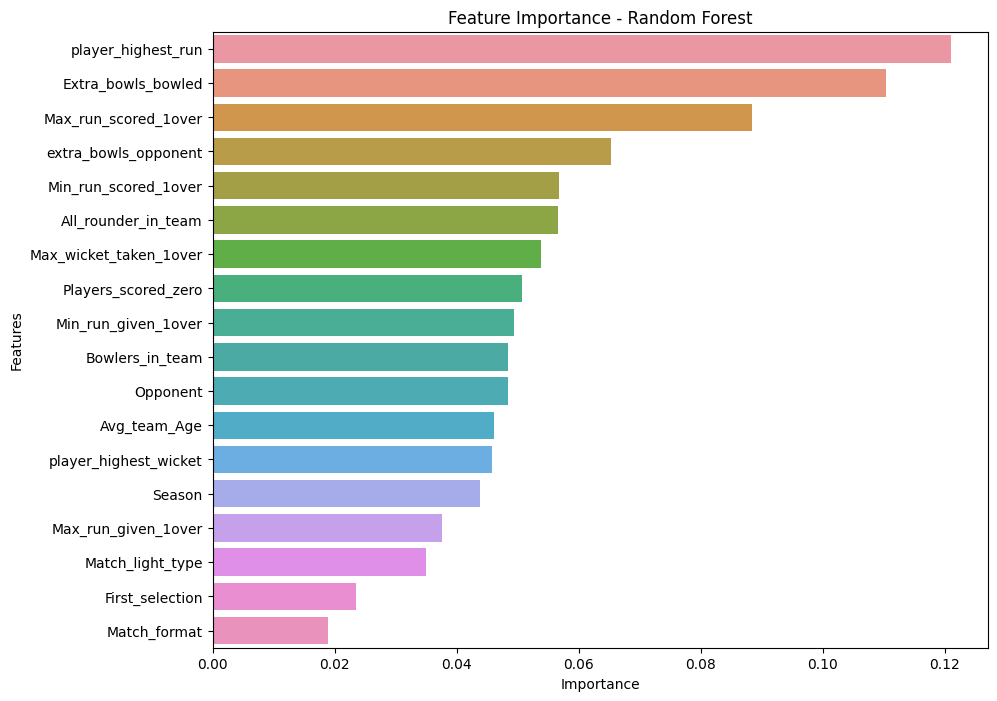

In [115]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Get feature importances from best_rf
feature_importance = best_rf.feature_importances_

# Step 2: Get feature names from x.columns
feature_names = x_train.columns

# Step 3: Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

# Step 4: Sort the DataFrame by Importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Step 5: Plotting feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


The feature importance plot from a Random Forest model highlights the relative importance of various features in predicting the target variable. Here are some business-related recommendations or insights based on the observed feature importances:

Focus on Key Players:

Features such as player_highest_run, player_highest_wicket, and Max_run_scored_1over are highly important. This suggests that the individual performance of key players has a significant impact on the outcome.
Recommendation: Invest in identifying and nurturing key players. Provide additional training and resources to high-performing players to maximize their impact.
Improve Bowling Performance:

Features like Max_wicket_taken_1over, Extra_bowls_bowled, and extra_bowls_opponent also have high importance. Effective bowling strategies are crucial.
Recommendation: Focus on improving bowling techniques and strategies. Analyze and minimize the number of extra balls bowled, which can be a key factor in controlling the game.
Optimize Team Composition:

Features such as Bowlers_in_team and All_rounder_in_team have noticeable importance.
Recommendation: Balance the team composition with a mix of specialized bowlers and all-rounders. This can provide both offensive and defensive capabilities, enhancing the team's overall performance.
Consider Match Conditions:

Match_format, Match_light_type, and Season are also relevant features.
Recommendation: Tailor strategies based on the match format and conditions. For instance, different approaches may be required for day vs. night matches, or T20 vs. ODI formats. Seasonal conditions can affect player performance and game dynamics.
Strategize Based on Opponents:

The feature Opponent has significant importance, indicating that the performance can vary depending on the opposing team.
Recommendation: Conduct in-depth analysis of past performances against specific opponents. Develop customized strategies to exploit their weaknesses and counter their strengths.
Leverage Experience and Selection:

Features like First_selection and Avg_team_Age indicate the importance of experience and initial team selection.
Recommendation: Consider the experience level of players when making team selections. Experienced players might handle high-pressure situations better, contributing to better performance.
Minimize Poor Performances:

Players_scored_zero is an important feature, suggesting that minimizing the number of players who score zero is critical.
Recommendation: Work on enhancing the consistency of all players. Provide targeted support to players who are prone to low scores to improve their reliability.
By focusing on these insights and recommendations, businesses (such as cricket teams or franchises) can develop more effective strategies, improve team performance, and potentially achieve better outcomes in their matches.